# Create and analyze trends across the summer stats from the Fourier Fits and compare with the Polynomial Fits

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
import pwlf #piecewise linear fits

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

## Load LSM for filtering

In [2]:
file_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds_lsm = xr.open_dataset(file_path)
ds_lsm

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

## load data from a couple of years to test Fourier results

In [3]:
%%time

# takes about 55 sec

# start with one year and lsm and add a coordinate for the year
year = 1961
input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/'+str(year)+'_summer_stats.nc'
ds = xr.open_dataset(input_path)
ds = ds.merge(ds_lsm)
ds = ds.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,1963,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds = ds.merge(ds_i)

ds

CPU times: user 90.6 ms, sys: 80.9 ms, total: 171 ms
Wall time: 179 ms


<xarray.Dataset> Size: 166MB
Dimensions:       (lat: 721, lon: 1440, time: 2)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 16B 1961-01-01 1962-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 17MB 135.0 135.0 ... 162.0 162.0
    SummerEnd     (time, lat, lon) float64 17MB 224.0 224.0 ... 232.0 232.0
    SummerTmax    (time, lat, lon) float64 17MB 179.0 179.0 ... 192.0 192.0
    SummerHeat    (time, lat, lon) float64 17MB 390.0 390.0 ... 221.4 221.4
    SummerLength  (time, lat, lon) float64 17MB 90.0 90.0 90.0 ... 71.0 71.0
    SummerRMSE    (time, lat, lon) float64 17MB 4.247 4.247 ... 3.733 3.733
    SummerR2      (time, lat, lon) float64 17MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerMeanT   (time, lat, lon) float64 17MB 240.5 240.5 ... 273.9 273.9
    SummerMeanHS  (time, lat, lon) float64 17MB 4.937 4.937 ... 3.118 3.118
    lsm           (time, lat, lon) float64 17MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0

### Map of summer length

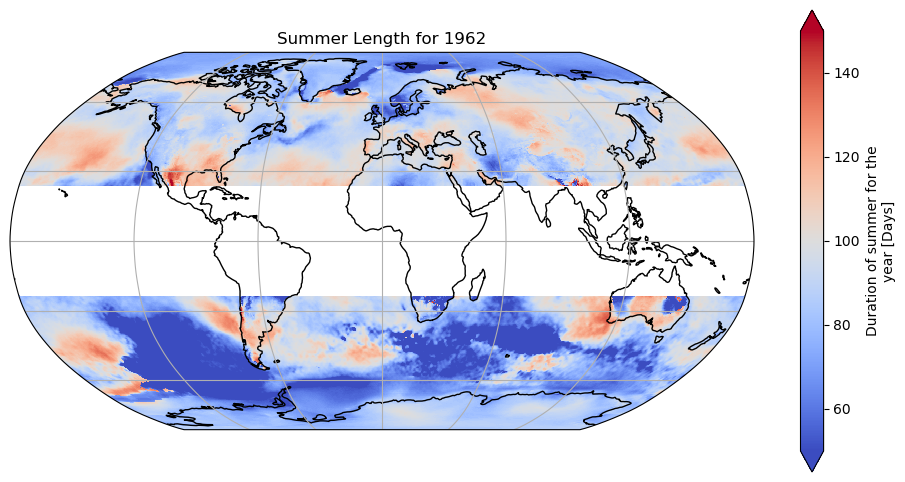

In [4]:
input_year=1962

# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

ds.SummerLength.sel(time=str(input_year)).where((ds.lat <= -23.5) | (ds.lat >= 23.5)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=50,
    vmax=150, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer Length for "+str(input_year))#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

## Pull in the coastal margins for use in data processing and write out full 1961-2023 Summer Stats for Fourier fit data

In [3]:
# write those results out for later use
input_path = '../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-CoastalMargins.nc'
results_ds = xr.open_dataset(input_path)



In [6]:
results_ds

<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    Coastal  (lat, lon) bool 1MB ...

## * Build and write out the full data set from Fourier fits including the coastal margin boolean

In [4]:
%%time

# takes ~4 min to load

# start with one year and lsm then coastal and add a coordinate for the year
year = 1961
input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/'+str(year)+'_summer_stats.nc'
ds_base = xr.open_dataset(input_path)
ds_base = ds_base.merge(ds_lsm) # add lsm
ds_base = ds_base.merge(results_ds) # add coastal flag
ds_base = ds_base.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,2024,1)

for year in input_years:
    input_path = '../../../Data/ERA5-global/Analysis/New-Fourier/'+str(year)+'_summer_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.merge(results_ds)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds_base = ds_base.merge(ds_i)

ds_base

CPU times: user 1min 37s, sys: 2min 34s, total: 4min 11s
Wall time: 4min 45s


<xarray.Dataset> Size: 6GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB 135.0 135.0 ... 160.0 160.0
    SummerEnd     (time, lat, lon) float64 523MB 224.0 224.0 ... 246.0 246.0
    SummerTmax    (time, lat, lon) float64 523MB 179.0 179.0 ... 231.0 231.0
    SummerHeat    (time, lat, lon) float64 523MB 390.0 390.0 ... 237.5 237.5
    SummerLength  (time, lat, lon) float64 523MB 90.0 90.0 90.0 ... 87.0 87.0
    SummerRMSE    (time, lat, lon) float64 523MB 4.247 4.247 ... 3.005 3.005
    SummerR2      (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerMeanT   (time, lat, lon) float64 523MB 240.5 240.5 ... 273.5 273.5
    SummerMeanHS  (time, lat, lon) float64 523MB 4.937 4.937 4.937 ... 2.73 2.73
    lsm           (time, lat, lon) float64 523MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0
    Coastal       (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [5]:
# re-add attributes which get lost on merge apparently
ds_base.SummerStart.attrs["long_name"] = "Start day of summer for the year (DOY in [1,365])"
ds_base.SummerStart.attrs["units"] = "Day of year"

ds_base.SummerEnd.attrs["long_name"] = "Last day of summer for the year (DOY in [1,365])"
ds_base.SummerEnd.attrs["units"] = "Day of year"

ds_base.SummerLength.attrs["long_name"] = "Duration of summer for the year"
ds_base.SummerLength.attrs["units"] = "Days"

ds_base.SummerTmax.attrs["long_name"] = "Day of max mean temp during summer for the year"
ds_base.SummerTmax.attrs["units"] = "Day of year"

ds_base.SummerHeat.attrs["long_name"] = "Accumulated heat during summer for the year"
ds_base.SummerHeat.attrs["units"] = "Degree-Days"

ds_base.SummerRMSE.attrs["long_name"] = "Root mean squared error of polynomial fit"
ds_base.SummerRMSE.attrs["units"] = "Degrees [K]"

ds_base.SummerR2.attrs["long_name"] = "Coefficient of determination (R-squared) of Fourier fit [NOT USED]"
ds_base.SummerR2.attrs["units"] = "Variance explained"

ds_base.SummerMeanT.attrs["long_name"] = "Mean temperature during the summer period"
ds_base.SummerMeanT.attrs["units"] = "Degrees [K]"

ds_base.lsm.attrs["long_name"] = "Land-sea mask - a measure of the amount of land in the cell"
ds_base.lsm.attrs["units"] = "(0 - 1)"

ds_base.SummerMeanHS.attrs["long_name"] = "Mean HS temperature during the summer period"
ds_base.SummerMeanHS.attrs["units"] = "Degrees [K]"

###
### also cast the Coastal as boolean?
###
ds_base.Coastal.values = ds_base.Coastal.values.astype(bool)
ds_base.Coastal.attrs["long_name"] = "Boolean value for whether a >30% land cell has at least one >80% water neighbor"
ds_base.Coastal.attrs["units"] = "true/false"

ds_base

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB 135.0 135.0 ... 160.0 160.0
    SummerEnd     (time, lat, lon) float64 523MB 224.0 224.0 ... 246.0 246.0
    SummerTmax    (time, lat, lon) float64 523MB 179.0 179.0 ... 231.0 231.0
    SummerHeat    (time, lat, lon) float64 523MB 390.0 390.0 ... 237.5 237.5
    SummerLength  (time, lat, lon) float64 523MB 90.0 90.0 90.0 ... 87.0 87.0
    SummerRMSE    (time, lat, lon) float64 523MB 4.247 4.247 ... 3.005 3.005
    SummerR2      (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    SummerMeanT   (time, lat, lon) float64 523MB 240.5 240.5 ... 273.5 273.5
    SummerMeanHS  (time, lat, lon) float64 523MB 4.937 4.937 4.937 ... 2.73 2.73
    lsm           (time, lat, lon) float64 523MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0
    Coastal       (time, lat, lon) bool 65MB False False False ... False False

In [7]:
# write out complete dataset with LSM and Coastal flags
output_path = '../../../Data/ERA5-global/Analysis/New-Fourier/1961-2023_ALL_summer_stats.nc'
ds_base.to_netcdf(output_path)

# create a COASTAL data file similar to the LAND and OCEAN ones we have so far as well
# output_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_COASTAL_summer_stats.nc'
# ds_coastal = ds_base.where(ds_base.Coastal)
# ds_coastal.to_netcdf(output_path)



# **********

# *** JUMP here after first running

In [9]:
ds = xr.open_dataset('../../../Data/ERA5-global/Analysis/New-Fourier/1961-2023_ALL_summer_stats.nc')
ds

<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB ...
    SummerEnd     (time, lat, lon) float64 523MB ...
    SummerTmax    (time, lat, lon) float64 523MB ...
    SummerHeat    (time, lat, lon) float64 523MB ...
    SummerLength  (time, lat, lon) float64 523MB ...
    SummerRMSE    (time, lat, lon) float64 523MB ...
    SummerR2      (time, lat, lon) float64 523MB ...
    SummerMeanT   (time, lat, lon) float64 523MB ...
    SummerMeanHS  (time, lat, lon) float64 523MB ...
    lsm           (time, lat, lon) float64 523MB ...
    Coastal       (time, lat, lon) bool 65MB ...

# **********

# Plots

In [4]:


# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"


### Global Land vs Ocean Summer Length

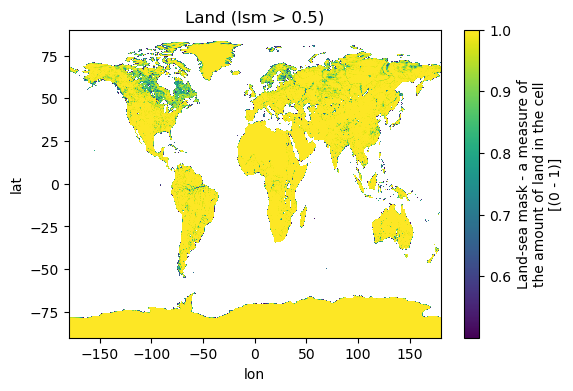

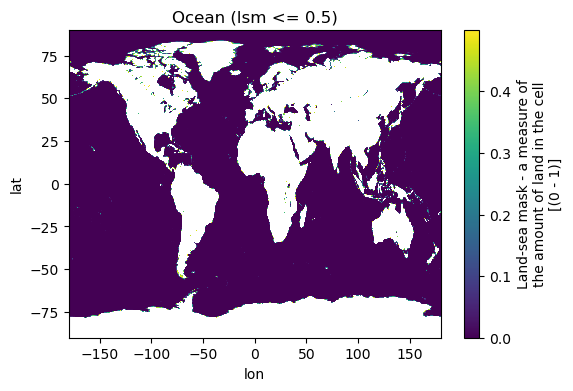

In [5]:
# can be land and inland small water
ds_land = ds.where(ds.lsm > 0.5)
ds_ocean = ds.where(ds.lsm <= 0.5)

plt.figure(figsize=(6,4))
#plt.subplot(111)
ds_land.lsm.sel(time='2020').plot()
plt.title("Land (lsm > 0.5)")
#plt.subplot(122)
plt.figure(figsize=(6,4))
ds_ocean.lsm.sel(time='2020').plot()
plt.title("Ocean (lsm <= 0.5)")
#plt.tight_layout()
plt.show()

In [8]:
ds_land

<xarray.Dataset> Size: 6GB
Dimensions:       (time: 63, lat: 721, lon: 1440)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB 135.0 135.0 135.0 ... nan nan
    SummerEnd     (time, lat, lon) float64 523MB 224.0 224.0 224.0 ... nan nan
    SummerTmax    (time, lat, lon) float64 523MB 179.0 179.0 179.0 ... nan nan
    SummerHeat    (time, lat, lon) float64 523MB 390.0 390.0 390.0 ... nan nan
    SummerLength  (time, lat, lon) float64 523MB 90.0 90.0 90.0 ... nan nan nan
    SummerRMSE    (time, lat, lon) float64 523MB 4.247 4.247 4.247 ... nan nan
    SummerR2      (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan
    SummerMeanT   (time, lat, lon) float64 523MB 240.5 240.5 240.5 ... nan nan
    SummerMeanHS  (time, lat, lon) float64 523MB 4.937 4.937 4.937 ... nan nan
    lsm           (time, lat, lon) float64 523MB 1.0 1.0 1.0 1.0 ... nan nan nan
    Coastal       (time, lat, lon) float64 523MB 0.0 0.0 0.0 0.0 ... nan nan nan

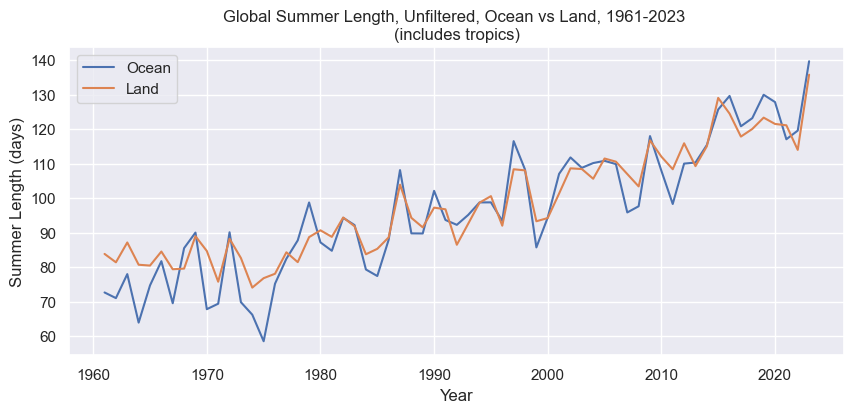

In [40]:


# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_land_sl = ds_land.SummerLength.weighted(weights).mean(dim=['lat','lon'])
wavg_ocean_sl = ds_ocean.SummerLength.weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_ocean_sl.time.dt.year, wavg_ocean_sl, label="Ocean")
plt.plot(wavg_land_sl.time.dt.year, wavg_land_sl, label="Land")

plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Summer Length, Unfiltered, Ocean vs Land, 1961-2023 \n(includes tropics)")
plt.legend()
plt.show()

## Global Mid-latitude Land vs Ocean

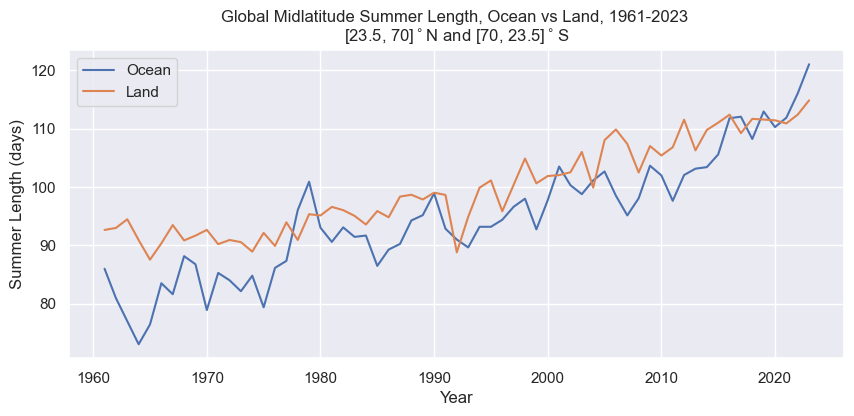

In [41]:
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_sl = ds_land.SummerLength.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_ocean_sl = ds_ocean.SummerLength.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_sl.time.dt.year, wavg_midlat_ocean_sl, label="Ocean")
plt.plot(wavg_midlat_land_sl.time.dt.year, wavg_midlat_land_sl, label="Land")
plt.xlabel("Year")
plt.ylabel("Summer Length (days)")
plt.title("Global Midlatitude Summer Length, Ocean vs Land, 1961-2023 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

#### Get mean and sd for earliest 15 and latest 15 years for each surface type

In [205]:
wavg_midlat_land_sl.sel(time=slice('1961','1975')).mean(), wavg_midlat_land_sl.sel(time=slice('1961','1975')).std()

(<xarray.DataArray 'SummerLength' ()> Size: 8B
 array(91.37164672),
 <xarray.DataArray 'SummerLength' ()> Size: 8B
 array(1.7301459))

In [206]:
wavg_midlat_land_sl.sel(time=slice('2009','2023')).mean(), wavg_midlat_land_sl.sel(time=slice('2009','2023')).std()

(<xarray.DataArray 'SummerLength' ()> Size: 8B
 array(110.15914113),
 <xarray.DataArray 'SummerLength' ()> Size: 8B
 array(2.59093116))

In [207]:
wavg_midlat_ocean_sl.sel(time=slice('1961','1975')).mean(), wavg_midlat_ocean_sl.sel(time=slice('1961','1975')).std()

(<xarray.DataArray 'SummerLength' ()> Size: 8B
 array(81.89362282),
 <xarray.DataArray 'SummerLength' ()> Size: 8B
 array(4.11638768))

In [208]:
wavg_midlat_ocean_sl.sel(time=slice('2009','2023')).mean(), wavg_midlat_ocean_sl.sel(time=slice('2009','2023')).std()

(<xarray.DataArray 'SummerLength' ()> Size: 8B
 array(108.11914576),
 <xarray.DataArray 'SummerLength' ()> Size: 8B
 array(6.09673718))

## Scatter plots of Ocean (<= 50% land) vs Land (> 50% land) for NH and SH, Start/End/Length

In [6]:
plot_vars = list(ds.data_vars)
remove_me = {'SummerTmax','SummerMeanHS','SummerRMSE','SummerR2','lsm','Coastal','SummerMeanT'}
plot_vars = [item for item in plot_vars if item not in remove_me]
plot_vars

['SummerStart', 'SummerEnd', 'SummerHeat', 'SummerLength']

In [40]:
%%time

# takes 36 sec

# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

# datasets of weighted averages for the midlatitudes
# for now, removing grid cells from averages where the mean summer temp was 0 K meaning no summer
# quick counts suggest this loses 1.5 - 2% of grid cells across the 63 years
# nearly all are in the SH ocean
nh_land_full = ds.where((ds.lsm > 0.5) & #(ds.SummerMeanT > 0) &
                             ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_ocean_full = ds.where((ds.lsm <= 0.5) & #(ds.SummerMeanT > 0) &
                              ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_full = ds.where((ds.lsm > 0.5) & #(ds.SummerMeanT > 0) & 
                             ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_full = ds.where((ds.lsm <= 0.5) & #(ds.SummerMeanT > 0) & 
                              ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

nh_land_an = ds.sel(time=slice('1990','2023')).where((ds.lsm > 0.5) & #(ds.SummerMeanT > 0) &
                                                          ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_ocean_an = ds.sel(time=slice('1990','2023')).where((ds.lsm <= 0.5) & #(ds.SummerMeanT > 0) &
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_an = ds.sel(time=slice('1990','2023')).where((ds.lsm > 0.5) & #(ds.SummerMeanT > 0) &
                                                          ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_an = ds.sel(time=slice('1990','2023')).where((ds.lsm <= 0.5) & #(ds.SummerMeanT > 0) &
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

# adding in baseline period for trends to put in paper
nh_land_base = ds.sel(time=slice('1961','1990')).where((ds.lsm > 0.5) & #(ds.SummerMeanT > 0) &
                                                          ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_ocean_base = ds.sel(time=slice('1961','1990')).where((ds.lsm <= 0.5) & #(ds.SummerMeanT > 0) &
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_base = ds.sel(time=slice('1961','1990')).where((ds.lsm > 0.5) & #(ds.SummerMeanT > 0) &
                                                          ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_base = ds.sel(time=slice('1961','1990')).where((ds.lsm <= 0.5) & #(ds.SummerMeanT > 0) &
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])


CPU times: user 22.2 s, sys: 22.7 s, total: 44.9 s
Wall time: 49 s


In [8]:
# plot properties so I can more easily tweak them
s = 18
lw = 4
alpha = 0.6
fs = 20

sns.set_theme(style="darkgrid")

## Same as above but Coast/Land/Ocean where Land does not include Coasts

In [11]:
#ds.where((ds.lsm > 0.5) & (ds.SummerMeanT == 0) & (ds.Coastal == False) & ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon']).count()
# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

#### removed ds.SummerMeanT > 0 in the below because with the Fourier fits it makes no difference in results

In [41]:
%%time

# 35 sec

nh_land_full = ds.where((ds.lsm > 0.5) &  (ds.Coastal == False) & #(ds.SummerMeanT > 0) &
                             ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_coast_full = ds.where((ds.Coastal)  & #& (ds.SummerMeanT > 0)
                              ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_full = ds.where((ds.lsm > 0.5)  & (ds.Coastal == False) & #& (ds.SummerMeanT > 0)
                             ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_coast_full = ds.where((ds.Coastal)  & #& (ds.SummerMeanT > 0)
                              ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

nh_land_an = ds.sel(time=slice('1990','2023')).where((ds.lsm > 0.5)  & (ds.Coastal == False) & #& (ds.SummerMeanT > 0)
                                                          ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_coast_an = ds.sel(time=slice('1990','2023')).where((ds.Coastal)  & #& (ds.SummerMeanT > 0)
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_an = ds.sel(time=slice('1990','2023')).where((ds.lsm > 0.5)  & (ds.Coastal == False) & #& (ds.SummerMeanT > 0)
                                                          ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_coast_an = ds.sel(time=slice('1990','2023')).where((ds.Coastal)  & #& (ds.SummerMeanT > 0)
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

# adding in baseline period to use for trends in the paper
nh_land_base = ds.sel(time=slice('1961','1990')).where((ds.lsm > 0.5)  & (ds.Coastal == False) & #& (ds.SummerMeanT > 0)
                                                          ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_coast_base = ds.sel(time=slice('1961','1990')).where((ds.Coastal)  & #& (ds.SummerMeanT > 0)
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_base = ds.sel(time=slice('1961','1990')).where((ds.lsm > 0.5)  & (ds.Coastal == False) & #& (ds.SummerMeanT > 0)
                                                          ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_coast_base = ds.sel(time=slice('1961','1990')).where((ds.Coastal)  & #& (ds.SummerMeanT > 0)
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])




CPU times: user 22.3 s, sys: 21.7 s, total: 44 s
Wall time: 47.7 s


#### Reformatted length only

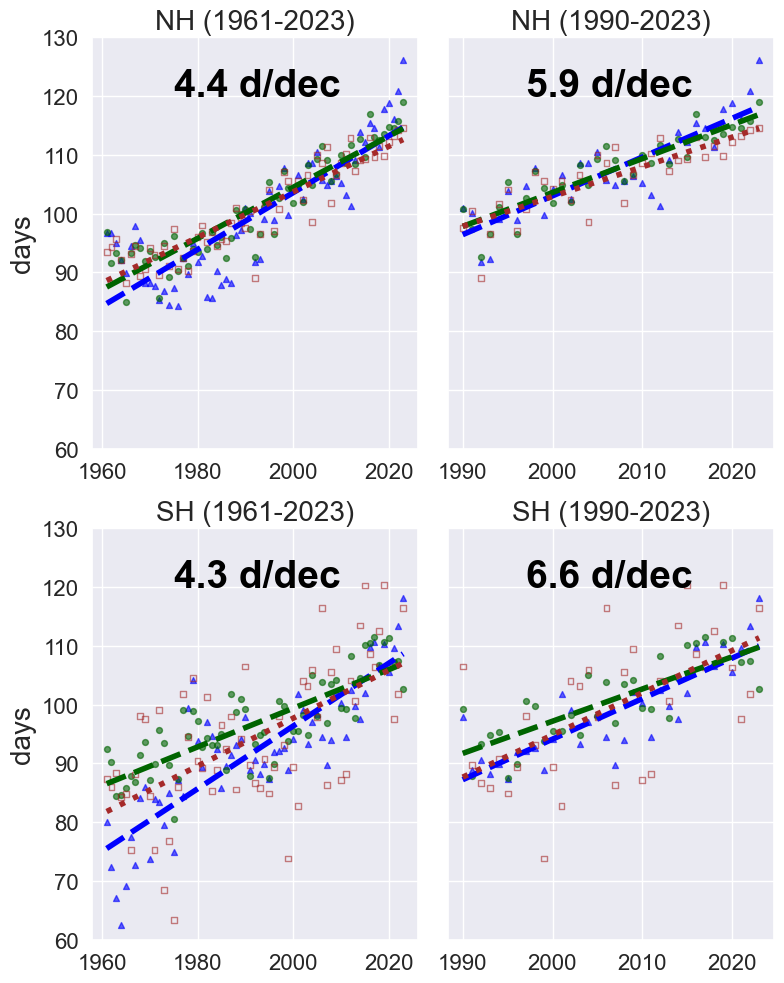

CPU times: user 480 ms, sys: 22.3 ms, total: 503 ms
Wall time: 507 ms


In [16]:
%%time

# takes 30 sec
#markers
l_m = 's'
o_m = '^'
c_m = 'o'


# create blank fig
fig = plt.figure(figsize = (8,10), layout='constrained')

# Full Time Period NH
ax1 = fig.add_subplot(2,2,1)

# linear fits for slope
x_land = nh_land_full.time.dt.year.values
y_land = nh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = nh_coast_full.time.dt.year.values
y_coast = nh_coast_full[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = nh_ocean_full.time.dt.year.values
y_ocean = nh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax1.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax1.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", s=s, marker=c_m, alpha=alpha)
ax1.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax1.scatter(x_land, y_land, label="NH Inland", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax1.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax1.set_title("NH (1961-2023)", fontsize = fs)
# Annotation
ann_y = (ax1.get_yticks())[-3]+10
ann_x = np.mean(ax1.get_xticks())-15
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
ax1.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' d/dec', fontsize=28, color='black', fontweight='bold')
         #''+str(np.round((slope_ocean+slope_land)*5,1))+r' $\frac{days}{decade}$', fontsize=28, color='purple', fontweight='bold')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16)
if i < 2:
    ylabel = 'DOY'
else:
    ylabel = 'days'
ax1.set_ylabel(ylabel, fontsize=fs)
ax1.set_ylim(60,130)
#ax1.legend(loc='best')

# Full time period SH
ax2 = fig.add_subplot(2,2,3)#, sharey=ax1)

# linear fits for slope
x_land = sh_land_full.time.dt.year.values
y_land = sh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = sh_coast_full.time.dt.year.values
y_coast = sh_coast_full[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = sh_ocean_full.time.dt.year.values
y_ocean = sh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax2.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax2.scatter(x_coast, y_coast, label="SH Coast", c="darkgreen", s=s, marker=c_m, alpha=alpha)
ax2.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax2.scatter(x_land, y_land, label="SH Inland", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax2.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax2.set_title("SH (1961-2023)", fontsize = fs)
ax2.set_ylabel('days', fontsize=fs)
# Annotation
ann_y = (ax2.get_yticks())[-3]+10
ann_x = np.mean(ax2.get_xticks())-15
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
ax2.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' d/dec', fontsize=28, color='black', fontweight='bold')
# ax2.text(np.min(x_land)+10, np.max(y_ocean)-2, 
#          r'$\frac{\Delta}{\Delta t} \approx $'+str(np.round((slope_ocean+slope_land)*5,1)), fontsize=28, color='purple', fontweight='bold')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=True)
ax2.set_ylim(60,130)
#ax2.legend(loc='best')


# Analysis time period NH
ax3 = fig.add_subplot(2,2,2, sharey=ax1)

# linear fits for slope
x_land = nh_land_an.time.dt.year.values
y_land = nh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = nh_coast_an.time.dt.year.values
y_coast = nh_coast_an[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = nh_ocean_an.time.dt.year.values
y_ocean = nh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax3.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax3.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax3.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", s=s, marker=c_m, alpha=alpha)
ax3.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax3.scatter(x_land, y_land, label="NH Inland", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax3.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax3.set_title("NH (1990-2023)", fontsize = fs)
# Annotation - units in per decade
ann_y = (ax3.get_yticks())[-3]+10
ann_x = np.mean(ax3.get_xticks())-8
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
ax3.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' d/dec', fontsize=28, color='black', fontweight='bold')
#ax3.set_ylabel('Days', fontsize=fs)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)
#ax3.legend(loc='best')


# Analysis time period SH
ax4 = fig.add_subplot(2,2,4, sharey=ax2)

# linear fits for slope
x_land = sh_land_an.time.dt.year.values
y_land = sh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = sh_coast_an.time.dt.year.values
y_coast = sh_coast_an[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = sh_ocean_an.time.dt.year.values
y_ocean = sh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax4.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax4.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax4.scatter(x_coast, y_coast, label="SH Coast", c="darkgreen", s=s, marker=c_m, alpha=alpha)
ax4.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax4.scatter(x_land, y_land, label="SH Inland", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax4.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax4.set_title("SH (1990-2023)", fontsize = fs)
# Annotation - units in per decade
ann_y = (ax4.get_yticks())[-3]+10
ann_x = np.mean(ax4.get_xticks())-8
    # plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
ax4.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' d/dec', fontsize=28, color='black', fontweight='bold')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
#ax3.legend(loc='best')


plt.tight_layout()
plt.savefig("./Plots/summer_length_2x2_plot.png",bbox_inches='tight')
plt.savefig("./Plots/summer_length_2x2_plot.pdf",bbox_inches='tight')
plt.show()


#### Reformatted Heat Only

In [18]:
v = 'SummerHeat'

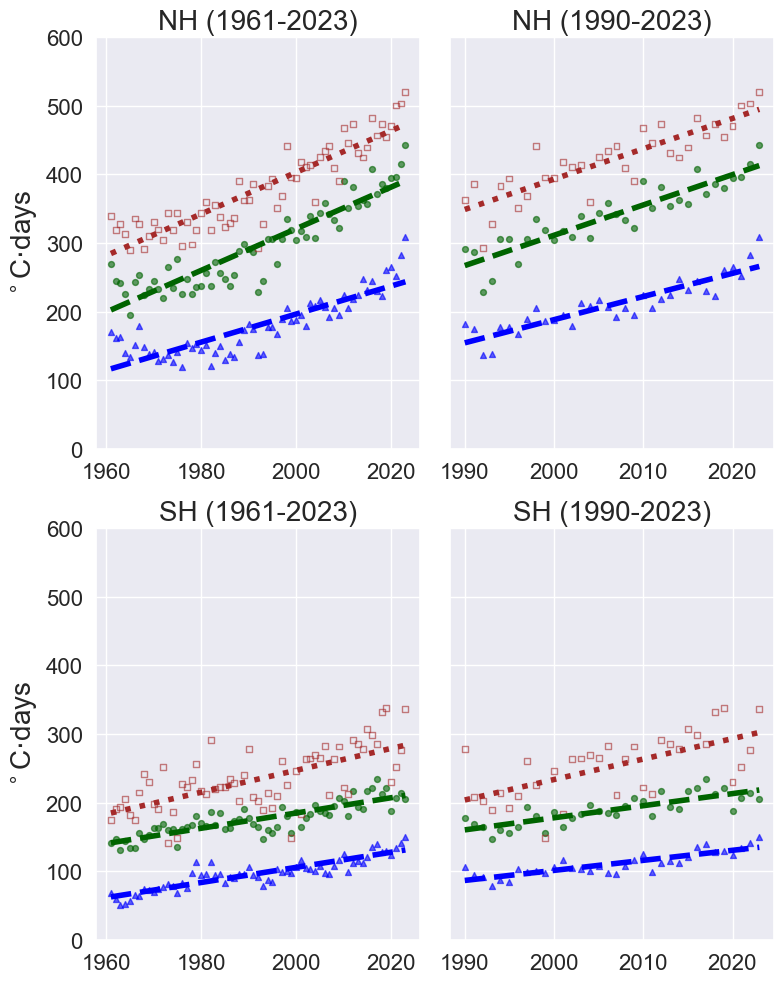

CPU times: user 492 ms, sys: 43.5 ms, total: 536 ms
Wall time: 560 ms


In [20]:
%%time

# takes 30 sec


# create blank fig
fig = plt.figure(figsize = (8,10), layout='constrained')

# Full Time Period NH
ax1 = fig.add_subplot(2,2,1)

# linear fits for slope
x_land = nh_land_full.time.dt.year.values
y_land = nh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = nh_coast_full.time.dt.year.values
y_coast = nh_coast_full[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = nh_ocean_full.time.dt.year.values
y_ocean = nh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax1.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax1.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", s=s, marker=c_m, alpha=alpha)
ax1.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax1.scatter(x_land, y_land, label="NH Inland", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax1.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax1.set_title("NH (1961-2023)", fontsize = fs)
# Annotation
ann_y = 500#(ax1.get_yticks())[-3]+10
ann_x = 1965#np.mean(ax1.get_xticks())-15
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
# ax1.text(ann_x, ann_y, 
#          ''+str(np.round(mean_slope,1))+r' $^{\circ}$C Days/10 yr', fontsize=fs, color='black', fontweight='bold')

# ax1.text(ann_x, ann_y, 
#          ''+str(25.4)+r' $^{\circ}$C$\cdot$d/dec', fontsize=fs, color='black', fontweight='bold')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16)
ax1.set_ylabel(r'$^\circ$C$\cdot$days', fontsize=fs)
ax1.set_ylim(0,600)
#ax1.legend(loc='best')

# Full time period SH
ax2 = fig.add_subplot(2,2,3)#, sharey=ax1)

# linear fits for slope
x_land = sh_land_full.time.dt.year.values
y_land = sh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = sh_coast_full.time.dt.year.values
y_coast = sh_coast_full[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = sh_ocean_full.time.dt.year.values
y_ocean = sh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax2.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax2.scatter(x_coast, y_coast, label="SH Coast", c="darkgreen", s=s, marker=c_m, alpha=alpha)
ax2.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax2.scatter(x_land, y_land, label="SH Inland", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax2.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax2.set_title("SH (1961-2023)", fontsize = fs)
ax2.set_ylabel(r'$^\circ$C$\cdot$days', fontsize=fs)
# Annotation
#ann_y = (ax2.get_yticks())[-3]+10
#ann_x = np.mean(ax2.get_xticks())-15
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
# ax2.text(ann_x, ann_y, 
#          ''+str(np.round(mean_slope,1))+r' $^{\circ}$C Days/10 yr', fontsize=fs, color='black', fontweight='bold')
# ax2.text(ann_x, ann_y, 
#          ''+str(11.5)+r' $^{\circ}$C$\cdot$d/dec', fontsize=fs, color='black', fontweight='bold')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=True)
ax2.set_ylim(0,600)
#ax2.legend(loc='best')


# Analysis time period NH
ax3 = fig.add_subplot(2,2,2, sharey=ax1)

# linear fits for slope
x_land = nh_land_an.time.dt.year.values
y_land = nh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = nh_coast_an.time.dt.year.values
y_coast = nh_coast_an[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = nh_ocean_an.time.dt.year.values
y_ocean = nh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax3.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax3.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax3.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", s=s, marker=c_m, alpha=alpha)
ax3.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax3.scatter(x_land, y_land, label="NH Inland", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax3.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax3.set_title("NH (1990-2023)", fontsize = fs)
# Annotation - units in per decade
#ann_y = (ax3.get_yticks())[-3]+10
ann_x = 1993#np.mean(ax3.get_xticks())-8
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
# ax3.text(ann_x, ann_y, 
#          ''+str(np.round(mean_slope,1))+r' $^{\circ}$C Days/10 yr', fontsize=fs, color='black', fontweight='bold')
# ax3.text(ann_x, ann_y, 
#          ''+str(39.0)+r' $^{\circ}$C$\cdot$d/dec', fontsize=fs, color='black', fontweight='bold')
#ax3.set_ylabel('Days', fontsize=fs)
#ax3.set_ylabel('Days', fontsize=fs)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)
#ax3.legend(loc='best')


# Analysis time period SH
ax4 = fig.add_subplot(2,2,4, sharey=ax2)

# linear fits for slope
x_land = sh_land_an.time.dt.year.values
y_land = sh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = sh_coast_an.time.dt.year.values
y_coast = sh_coast_an[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = sh_ocean_an.time.dt.year.values
y_ocean = sh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax4.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax4.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax4.scatter(x_coast, y_coast, label="SH Coast", c="darkgreen", s=s, marker=c_m, alpha=alpha)
ax4.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax4.scatter(x_land, y_land, label="SH Inland", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax4.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax4.set_title("SH (1990-2023)", fontsize = fs)
# Annotation - units in per decade
#ann_y = (ax4.get_yticks())[-3]+10
ann_x = 1993#np.mean(ax4.get_xticks())-8
    # plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
# ax4.text(ann_x, ann_y, 
#          ''+str(np.round(mean_slope,1))+r' $^{\circ}$C Days/10 yr', fontsize=fs, color='black', fontweight='bold')
# ax4.text(ann_x, ann_y, 
#          ''+str(16.0)+r' $^{\circ}$C$\cdot$d/dec', fontsize=fs, color='black', fontweight='bold')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
#ax3.legend(loc='best')


plt.tight_layout()
plt.savefig("./Plots/summer_heat_2x2_plot.png",bbox_inches='tight')
plt.savefig("./Plots/summer_heat_2x2_plot.pdf",bbox_inches='tight')
plt.show()


#### no mean slope labels

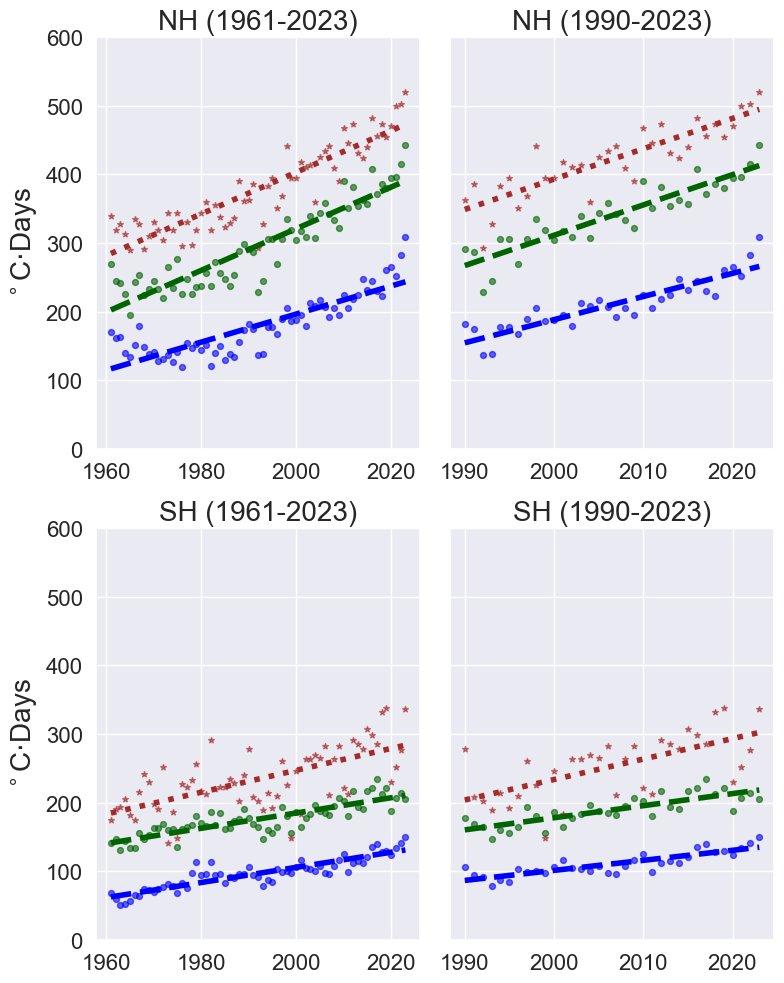

CPU times: user 331 ms, sys: 29.4 ms, total: 360 ms
Wall time: 402 ms


In [31]:
%%time

# takes 30 sec


# create blank fig
fig = plt.figure(figsize = (8,10), layout='constrained')

# Full Time Period NH
ax1 = fig.add_subplot(2,2,1)

# linear fits for slope
x_land = nh_land_full.time.dt.year.values
y_land = nh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = nh_coast_full.time.dt.year.values
y_coast = nh_coast_full[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = nh_ocean_full.time.dt.year.values
y_ocean = nh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax1.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, alpha=alpha)
ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax1.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", s=s, alpha=alpha)
ax1.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax1.scatter(x_land, y_land, label="NH Inland", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
ax1.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax1.set_title("NH (1961-2023)", fontsize = fs)
# Annotation
ann_y = 500#(ax1.get_yticks())[-3]+10
ann_x = 1965#np.mean(ax1.get_xticks())-15
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
# ax1.text(ann_x, ann_y, 
#          ''+str(np.round(mean_slope,1))+r' $^{\circ}$C Days/10 yr', fontsize=fs, color='black', fontweight='bold')

# ax1.text(ann_x, ann_y, 
#          ''+str(25.4)+r' $^{\circ}$C$\cdot$d/dec', fontsize=fs, color='black', fontweight='bold')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16)
ax1.set_ylabel(r'$^\circ$C$\cdot$Days', fontsize=fs)
ax1.set_ylim(0,600)
#ax1.legend(loc='best')

# Full time period SH
ax2 = fig.add_subplot(2,2,3)#, sharey=ax1)

# linear fits for slope
x_land = sh_land_full.time.dt.year.values
y_land = sh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = sh_coast_full.time.dt.year.values
y_coast = sh_coast_full[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = sh_ocean_full.time.dt.year.values
y_ocean = sh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax2.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, alpha=alpha)
ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax2.scatter(x_coast, y_coast, label="SH Coast", c="darkgreen", s=s, alpha=alpha)
ax2.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax2.scatter(x_land, y_land, label="SH Inland", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
ax2.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax2.set_title("SH (1961-2023)", fontsize = fs)
ax2.set_ylabel(r'$^\circ$C$\cdot$Days', fontsize=fs)
# Annotation
#ann_y = (ax2.get_yticks())[-3]+10
#ann_x = np.mean(ax2.get_xticks())-15
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
# ax2.text(ann_x, ann_y, 
#          ''+str(np.round(mean_slope,1))+r' $^{\circ}$C Days/10 yr', fontsize=fs, color='black', fontweight='bold')
# ax2.text(ann_x, ann_y, 
#          ''+str(11.5)+r' $^{\circ}$C$\cdot$d/dec', fontsize=fs, color='black', fontweight='bold')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=True)
ax2.set_ylim(0,600)
#ax2.legend(loc='best')


# Analysis time period NH
ax3 = fig.add_subplot(2,2,2, sharey=ax1)

# linear fits for slope
x_land = nh_land_an.time.dt.year.values
y_land = nh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = nh_coast_an.time.dt.year.values
y_coast = nh_coast_an[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = nh_ocean_an.time.dt.year.values
y_ocean = nh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax3.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, alpha=alpha)
ax3.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax3.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", s=s, alpha=alpha)
ax3.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax3.scatter(x_land, y_land, label="NH Inland", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
ax3.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax3.set_title("NH (1990-2023)", fontsize = fs)
# Annotation - units in per decade
#ann_y = (ax3.get_yticks())[-3]+10
ann_x = 1993#np.mean(ax3.get_xticks())-8
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
# ax3.text(ann_x, ann_y, 
#          ''+str(np.round(mean_slope,1))+r' $^{\circ}$C Days/10 yr', fontsize=fs, color='black', fontweight='bold')
# ax3.text(ann_x, ann_y, 
#          ''+str(39.0)+r' $^{\circ}$C$\cdot$d/dec', fontsize=fs, color='black', fontweight='bold')
#ax3.set_ylabel('Days', fontsize=fs)
#ax3.set_ylabel('Days', fontsize=fs)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)
#ax3.legend(loc='best')


# Analysis time period SH
ax4 = fig.add_subplot(2,2,4, sharey=ax2)

# linear fits for slope
x_land = sh_land_an.time.dt.year.values
y_land = sh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_coast = sh_coast_an.time.dt.year.values
y_coast = sh_coast_an[v].values
coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
poly_coast = np.poly1d(coefs_coast)
slope_coast = np.round(coefs_coast[0],2)
slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_coast)
ss_total = np.sum((y_coast - ymean)**2)
ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_coast = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = sh_ocean_an.time.dt.year.values
y_ocean = sh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax4.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, alpha=alpha)
ax4.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax4.scatter(x_coast, y_coast, label="SH Coast", c="darkgreen", s=s, alpha=alpha)
ax4.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
     label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
ax4.scatter(x_land, y_land, label="SH Inland", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
ax4.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax4.set_title("SH (1990-2023)", fontsize = fs)
# Annotation - units in per decade
#ann_y = (ax4.get_yticks())[-3]+10
ann_x = 1993#np.mean(ax4.get_xticks())-8
    # plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
if (slope_ocean < 0):
    mean_slope = mean_slope * -1
# ax4.text(ann_x, ann_y, 
#          ''+str(np.round(mean_slope,1))+r' $^{\circ}$C Days/10 yr', fontsize=fs, color='black', fontweight='bold')
# ax4.text(ann_x, ann_y, 
#          ''+str(16.0)+r' $^{\circ}$C$\cdot$d/dec', fontsize=fs, color='black', fontweight='bold')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
#ax3.legend(loc='best')


plt.tight_layout()
plt.savefig("./Plots/summer_heat_4x4_plot.png")
plt.show()


#### reset plot vars

In [ ]:
plot_vars = list(ds.data_vars)
remove_me = {'SummerTmax','SummerMeanHS','SummerRMSE','SummerR2','lsm','Coastal','SummerMeanT'}
plot_vars = [item for item in plot_vars if item not in remove_me]
plot_vars

### Reformatted without slopes for paper and only 1990-2023

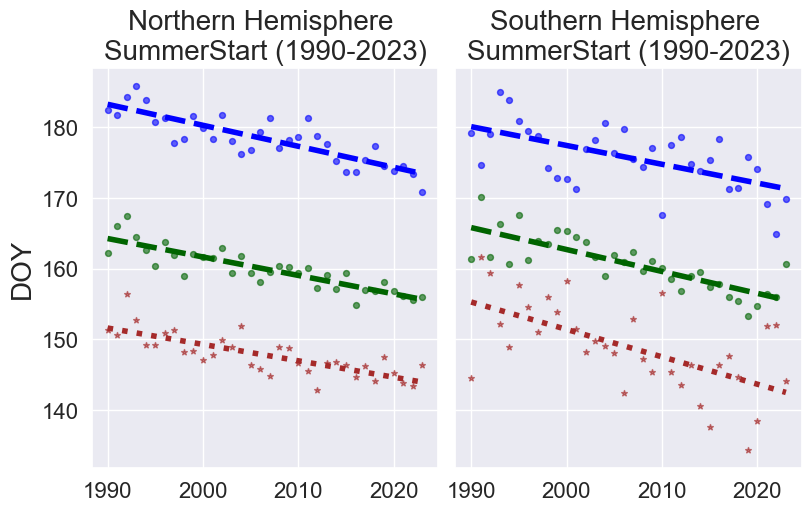

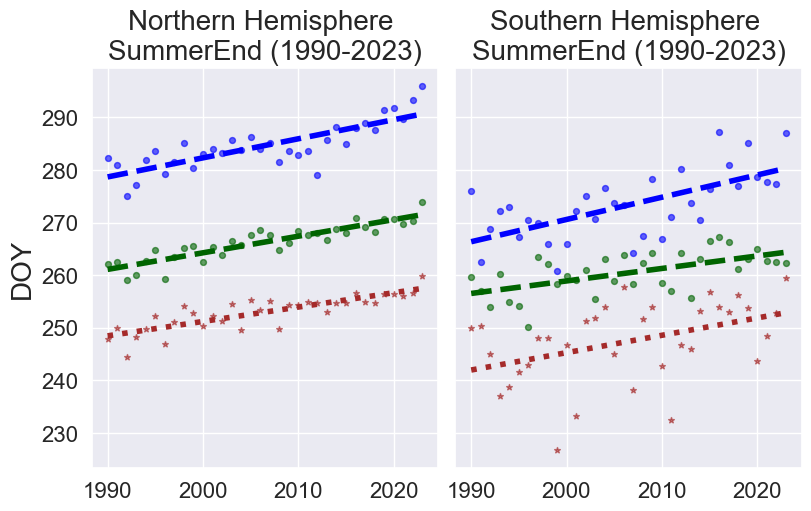

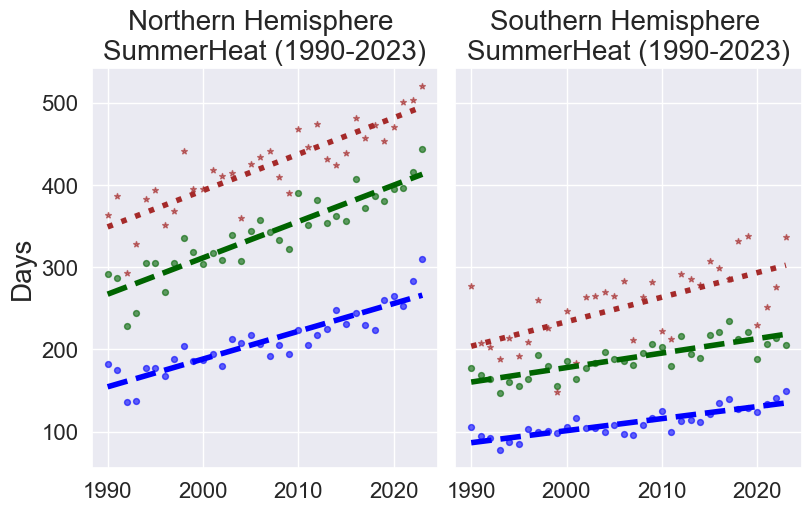

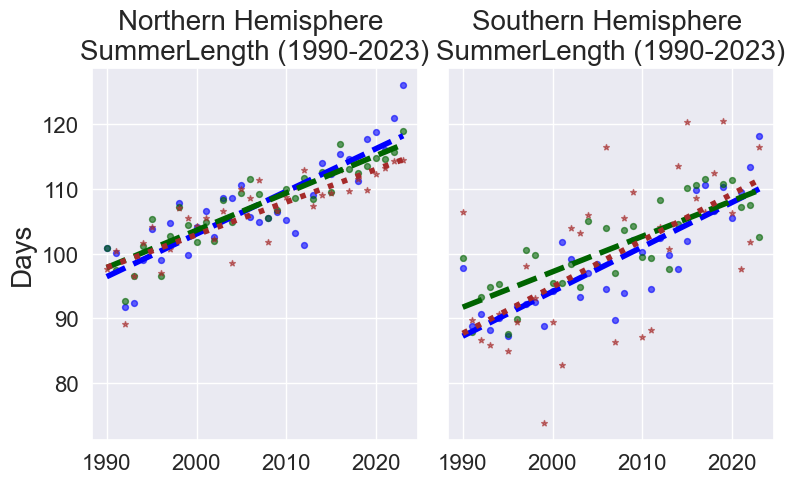

CPU times: user 825 ms, sys: 109 ms, total: 934 ms
Wall time: 1.04 s


In [118]:
%%time

# takes 30 sec



# loop through all plot variables
for i,v in enumerate(plot_vars):

    # create blank fig
    fig = plt.figure(figsize = (8,5), layout='constrained')
    
    # # Full Time Period NH
    # ax1 = fig.add_subplot(1,4,1)

    # # linear fits for slope
    # x_land = nh_land_full.time.dt.year.values
    # y_land = nh_land_full[v].values
    # coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    # poly_land = np.poly1d(coefs_land)
    # slope_land = np.round(coefs_land[0],2)
    # slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # # add in R^2 and RMSE
    # ymean = np.mean(y_land)
    # ss_total = np.sum((y_land - ymean)**2)
    # ss_res = np.sum((y_land - poly_land(x_land))**2)
    # #rmse = np.sqrt(ss_res/365.0)
    # r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # # linear fits for slope
    # x_coast = nh_coast_full.time.dt.year.values
    # y_coast = nh_coast_full[v].values
    # coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    # poly_coast = np.poly1d(coefs_coast)
    # slope_coast = np.round(coefs_coast[0],2)
    # slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
    # # add in R^2 and RMSE
    # ymean = np.mean(y_coast)
    # ss_total = np.sum((y_coast - ymean)**2)
    # ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
    # #rmse = np.sqrt(ss_res/365.0)
    # r_squared_coast = np.round(1 - (ss_res / ss_total),2)

    # # linear fits for slope
    # x_ocean = nh_ocean_full.time.dt.year.values
    # y_ocean = nh_ocean_full[v].values
    # coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    # poly_ocean = np.poly1d(coefs_ocean)
    # slope_ocean = np.round(coefs_ocean[0],2)
    # slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # # add in R^2 and RMSE
    # ymean = np.mean(y_ocean)
    # ss_total = np.sum((y_ocean - ymean)**2)
    # ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    # #rmse = np.sqrt(ss_res/365.0)
    # r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # # plot data
    # ax1.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, alpha=alpha)
    # ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
    #      label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    # ax1.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", s=s, alpha=alpha)
    # ax1.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
    #      label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
    # ax1.scatter(x_land, y_land, label="NH Inland", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
    # ax1.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
    #      label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    # ax1.set_title("Northern Hemisphere \n" + v + " (1961-2023)", fontsize = fs)
    # # Annotation
    # ann_y = (ax1.get_yticks())[-3]+8
    # ann_x = np.mean(ax1.get_xticks())-5
    # # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax1.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    #          #''+str(np.round((slope_ocean+slope_land)*5,1))+r' $\frac{days}{decade}$', fontsize=28, color='purple', fontweight='bold')
    # plt.tick_params('x', labelsize=16)
    # plt.tick_params('y', labelsize=16)
    # if i < 2:
    #     ylabel = 'DOY'
    # else:
    #     ylabel = 'Days'
    # ax1.set_ylabel(ylabel, fontsize=fs)
    # #ax1.legend(loc='best')

    # # Full time period SH
    # ax2 = fig.add_subplot(1,4,2, sharey=ax1)

    # # linear fits for slope
    # x_land = sh_land_full.time.dt.year.values
    # y_land = sh_land_full[v].values
    # coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    # poly_land = np.poly1d(coefs_land)
    # slope_land = np.round(coefs_land[0],2)
    # slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # # add in R^2 and RMSE
    # ymean = np.mean(y_land)
    # ss_total = np.sum((y_land - ymean)**2)
    # ss_res = np.sum((y_land - poly_land(x_land))**2)
    # #rmse = np.sqrt(ss_res/365.0)
    # r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # # linear fits for slope
    # x_coast = sh_coast_full.time.dt.year.values
    # y_coast = sh_coast_full[v].values
    # coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    # poly_coast = np.poly1d(coefs_coast)
    # slope_coast = np.round(coefs_coast[0],2)
    # slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
    # # add in R^2 and RMSE
    # ymean = np.mean(y_coast)
    # ss_total = np.sum((y_coast - ymean)**2)
    # ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
    # #rmse = np.sqrt(ss_res/365.0)
    # r_squared_coast = np.round(1 - (ss_res / ss_total),2)

    # # linear fits for slope
    # x_ocean = sh_ocean_full.time.dt.year.values
    # y_ocean = sh_ocean_full[v].values
    # coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    # poly_ocean = np.poly1d(coefs_ocean)
    # slope_ocean = np.round(coefs_ocean[0],2)
    # slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # # add in R^2 and RMSE
    # ymean = np.mean(y_ocean)
    # ss_total = np.sum((y_ocean - ymean)**2)
    # ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    # #rmse = np.sqrt(ss_res/365.0)
    # r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # # plot data
    # ax2.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, alpha=alpha)
    # ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
    #      label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    # ax2.scatter(x_coast, y_coast, label="SH Coast", c="darkgreen", s=s, alpha=alpha)
    # ax2.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
    #      label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
    # ax2.scatter(x_land, y_land, label="SH Inland", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
    # ax2.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
    #      label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    # ax2.set_title("Southern Hemisphere \n" + v + " (1961-2023)", fontsize = fs)
    # # Annotation
    # ann_y = (ax2.get_yticks())[-3]+8
    # ann_x = np.mean(ax2.get_xticks())-5
    # # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax2.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    # # ax2.text(np.min(x_land)+10, np.max(y_ocean)-2, 
    # #          r'$\frac{\Delta}{\Delta t} \approx $'+str(np.round((slope_ocean+slope_land)*5,1)), fontsize=28, color='purple', fontweight='bold')
    # plt.tick_params('x', labelsize=16)
    # plt.tick_params('y', labelsize=6, labelleft=False)
    # #ax2.legend(loc='best')
    

    # Analysis time period NH
    ax3 = fig.add_subplot(1,2,1)

    # linear fits for slope
    x_land = nh_land_an.time.dt.year.values
    y_land = nh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_coast = nh_coast_an.time.dt.year.values
    y_coast = nh_coast_an[v].values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0],2)
    slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_coast)
    ss_total = np.sum((y_coast - ymean)**2)
    ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_coast = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = nh_ocean_an.time.dt.year.values
    y_ocean = nh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax3.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, alpha=alpha)
    ax3.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    ax3.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", s=s, alpha=alpha)
    ax3.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
         label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
    ax3.scatter(x_land, y_land, label="NH Inland", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
    ax3.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax3.set_title("Northern Hemisphere \n" + v + " (1990-2023)", fontsize = fs)
    # Annotation - units in per decade
    # ann_y = (ax3.get_yticks())[-3]+8
    # ann_x = np.mean(ax3.get_xticks())-5
    # # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax3.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=16)
    if i < 2:
        ylabel = 'DOY'
    else:
        ylabel = 'Days'
    ax3.set_ylabel(ylabel, fontsize=fs)
    #ax3.legend(loc='best')

    
    # Analysis time period SH
    ax4 = fig.add_subplot(1,2,2, sharey=ax3)

    # linear fits for slope
    x_land = sh_land_an.time.dt.year.values
    y_land = sh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_coast = sh_coast_an.time.dt.year.values
    y_coast = sh_coast_an[v].values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0],2)
    slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_coast)
    ss_total = np.sum((y_coast - ymean)**2)
    ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_coast = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = sh_ocean_an.time.dt.year.values
    y_ocean = sh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax4.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, alpha=alpha)
    ax4.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    ax4.scatter(x_coast, y_coast, label="SH Coast", c="darkgreen", s=s, alpha=alpha)
    ax4.plot(x_coast, poly_coast(x_coast), linestyle="dashed", linewidth=lw, color='darkgreen', 
         label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
    ax4.scatter(x_land, y_land, label="SH Inland", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
    ax4.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax4.set_title("Southern Hemisphere \n" + v + " (1990-2023)", fontsize = fs)
    # Annotation - units in per decade
    # ann_y = (ax4.get_yticks())[-3]+8
    # ann_x = np.mean(ax4.get_xticks())-5
    #     # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax4.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=6, labelleft=False)
    #ax3.legend(loc='best')


plt.tight_layout()
plt.show()

#### Mean accumulated heat past decade for each surface

In [159]:
mean_nh_all_heat = ds.SummerHeat.sel(time=slice('2014','2023')).where(((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon']).mean()
mean_nh_land_heat = ds.SummerHeat.sel(time=slice('2014','2023')).where((ds.lsm > 0.5) &  (ds.Coastal == False) & ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon']).mean()
mean_nh_coast_heat = ds.SummerHeat.sel(time=slice('2014','2023')).where((ds.Coastal == True) & ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon']).mean()
mean_nh_ocean_heat = ds.SummerHeat.sel(time=slice('2014','2023')).where((ds.lsm <= 0.5) & ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon']).mean()
print(mean_nh_all_heat, mean_nh_land_heat, mean_nh_coast_heat, mean_nh_ocean_heat)
mean_sh_all_heat = ds.SummerHeat.sel(time=slice('2014','2023')).where(((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon']).mean()
mean_sh_land_heat = ds.SummerHeat.sel(time=slice('2014','2023')).where((ds.lsm > 0.5) &  (ds.Coastal == False) & ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon']).mean()
mean_sh_coast_heat = ds.SummerHeat.sel(time=slice('2014','2023')).where((ds.Coastal == True) & ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon']).mean()
mean_sh_ocean_heat = ds.SummerHeat.sel(time=slice('2014','2023')).where((ds.lsm <= 0.5) & ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon']).mean()
print(mean_sh_all_heat, mean_sh_land_heat, mean_sh_coast_heat, mean_sh_ocean_heat)


<xarray.DataArray 'SummerHeat' ()> Size: 8B
array(362.41495456) <xarray.DataArray 'SummerHeat' ()> Size: 8B
array(472.56096738) <xarray.DataArray 'SummerHeat' ()> Size: 8B
array(391.66828197) <xarray.DataArray 'SummerHeat' ()> Size: 8B
array(254.51548749)
<xarray.DataArray 'SummerHeat' ()> Size: 8B
array(146.20675998) <xarray.DataArray 'SummerHeat' ()> Size: 8B
array(293.49208342) <xarray.DataArray 'SummerHeat' ()> Size: 8B
array(211.16985281) <xarray.DataArray 'SummerHeat' ()> Size: 8B
array(131.2392434)


#### Mean summer start date in the SH all surface, 1961-1975 vs 2009-2023

In [163]:

mean_sh_all_start196175 = ds.SummerStart.sel(time=slice('1961','1970')).where( ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon']).mean()
mean_sh_all_start200923 = ds.SummerStart.sel(time=slice('2014','2023')).where( ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon']).mean()
mean_sh_land_start196175 = ds.SummerStart.sel(time=slice('1961','1970')).where((ds.lsm > 0.5) &  (ds.Coastal == False) & ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon']).mean()
mean_sh_land_start200923 = ds.SummerStart.sel(time=slice('2014','2023')).where((ds.lsm > 0.5) &  (ds.Coastal == False) & ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon']).mean()
# mean_sh_coast_start = ds.SummerStart.sel(time=slice('2014','2023')).where((ds.Coastal == True) & ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon']).mean()
# mean_sh_ocean_start = ds.SummerStart.sel(time=slice('2014','2023')).where((ds.lsm <= 0.5) & ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon']).mean()
print(mean_sh_all_start196175, mean_sh_all_start200923, mean_sh_land_start196175, mean_sh_land_start200923)


<xarray.DataArray 'SummerStart' ()> Size: 8B
array(174.19589672) <xarray.DataArray 'SummerStart' ()> Size: 8B
array(169.78631139) <xarray.DataArray 'SummerStart' ()> Size: 8B
array(152.14232068) <xarray.DataArray 'SummerStart' ()> Size: 8B
array(143.78002943)


In [165]:
sh_land_taylor = ds.SummerStart.sel(time=slice('2012','2014')).where((ds.lsm > 0.5) &  (ds.Coastal == False) & ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])
sh_land_taylor

<xarray.DataArray 'SummerStart' (time: 3)> Size: 24B
array([143.57233014, 146.40839686, 140.62926013])
Coordinates:
  * time     (time) datetime64[ns] 24B 2012-01-01 2013-01-01 2014-01-01

### CATEGORICAL Scatterplots for paper

#### build data frame

In [42]:
plot_vars = list(ds.data_vars)
remove_me = {'SummerR2','lsm','Coastal','SummerMeanHS','SummerTmax',
 'SummerRMSE',
 'SummerMeanT' }
plot_vars = [item for item in plot_vars if item not in remove_me]
plot_vars

['SummerStart', 'SummerEnd', 'SummerHeat', 'SummerLength']

In [43]:
%%time

# takes 20 sec

nh_full = ds.where(((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])
sh_full = ds.where(((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])
nh_an = ds.sel(time=slice('1990','2023')).where(((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])
sh_an = ds.sel(time=slice('1990','2023')).where(((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

# adding in baseline period for paper
nh_base = ds.sel(time=slice('1961','1990')).where(((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])
sh_base = ds.sel(time=slice('1961','1990')).where(((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])


CPU times: user 10.9 s, sys: 11 s, total: 21.9 s
Wall time: 23.6 s


In [44]:

# Initialize data 
plot_data = []
p_thresh = 0.05 # significance level for conf int


# loop through all plot variables
for i,v in enumerate(plot_vars):

    # full time period NH
    
    # ALL linear fits for slope
    x = nh_full.time.dt.year.values
    y = nh_full[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2) # mult by 10 to get days/decade
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  # mult by 10 to get days/decade

    # get R^2, RMSE, SE, and 95% conf int on slope value
    # help from https://mountain-hydrology-research-group.github.io/data-analysis/modules/module4/lab4-3.html
    # and https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week3/confidence_intervals.html

    ### *** Confirmed that the last value above is the standard error of the slope and the t-value is 2 so the 95% conf intervals are 2x the slope_all_* value
    # ymean = np.mean(y)
    # sst = np.sum((y - ymean)**2)
    # sst_x = np.sum((x - np.mean(x))**2)
    # sse = np.sum((y - poly_all(x))**2)
    # rmse = np.sqrt(sse/365.0)
    # r_squared = np.round(1 - (sse / sst),2)
    # n = len(x)
    # dof = n - 2
    # s = np.sqrt(sse/dof)
    # # std err of gradient
    # sB1 = s/np.sqrt(sst_x) *10 # mult by 10 to get days/decade
    # # t-value
    # t = stats.t.ppf(1 - p_thresh/2, dof)
    # # upper/lower ci on slope
    # slope_upper = slope_all + t*sB1
    # slope_lower = slope_all - t*sB1
    # ci = (slope_upper - slope_lower)/2

    # # quick comparison to what scipy stats linregress gives us
    # B1,B0,RR,P,SB1 = stats.linregress(x,y)
    # t_crit = stats.t.ppf(0.975,dof)
    # # calculate the 95% confidence interval on the slope
    # confidence_interval_slope = t_crit*SB1
    # print("The true value of the slope from linregress is then", np.round(B1*10,2), "+/-", np.round(confidence_interval_slope*10,2))

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'NH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1961-2023'}
    plot_data.append(temp_data)

    
    
    # LAND linear fits for slope
    x_land = nh_land_full.time.dt.year.values
    y_land = nh_land_full[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'NH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1961-2023'}
    plot_data.append(temp_data)
    

    # COAST linear fits for slope
    x_coast = nh_coast_full.time.dt.year.values
    y_coast = nh_coast_full[v].values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0]*10,2)
    slope_coast_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Coast', 'Hemisphere':'NH', 'Slope':slope_coast, 'SE':slope_coast_sd, 'Period':'1961-2023'}
    plot_data.append(temp_data)

    # OCEAN linear fits for slope
    x_ocean = nh_ocean_full.time.dt.year.values
    y_ocean = nh_ocean_full[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'NH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1961-2023'}
    plot_data.append(temp_data)

    
    # full time period SH

    # ALL linear fits for slope
    x = sh_full.time.dt.year.values
    y = sh_full[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2)
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'SH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1961-2023'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_land = sh_land_full.time.dt.year.values
    y_land = sh_land_full[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'SH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1961-2023'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_coast = sh_coast_full.time.dt.year.values
    y_coast = sh_coast_full[v].values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0]*10,2)
    slope_coast_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Coast', 'Hemisphere':'SH', 'Slope':slope_coast, 'SE':slope_coast_sd, 'Period':'1961-2023'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_ocean = sh_ocean_full.time.dt.year.values
    y_ocean = sh_ocean_full[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'SH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1961-2023'}
    plot_data.append(temp_data)

    # Analysis time period NH

    # ALL linear fits for slope
    x = nh_an.time.dt.year.values
    y = nh_an[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2)
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'NH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1990-2023'}
    plot_data.append(temp_data)
    
    # linear fits for slope
    x_land = nh_land_an.time.dt.year.values
    y_land = nh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'NH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1990-2023'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_coast = nh_coast_an.time.dt.year.values
    y_coast = nh_coast_an[v].values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0]*10,2)
    slope_coast_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Coast', 'Hemisphere':'NH', 'Slope':slope_coast, 'SE':slope_coast_sd, 'Period':'1990-2023'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_ocean = nh_ocean_an.time.dt.year.values
    y_ocean = nh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'NH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1990-2023'}
    plot_data.append(temp_data)

    # Analysis time period SH

    # ALL linear fits for slope
    x = sh_an.time.dt.year.values
    y = sh_an[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2)
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'SH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1990-2023'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_land = sh_land_an.time.dt.year.values
    y_land = sh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'SH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1990-2023'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_coast = sh_coast_an.time.dt.year.values
    y_coast = sh_coast_an[v].values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0]*10,2)
    slope_coast_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Coast', 'Hemisphere':'SH', 'Slope':slope_coast, 'SE':slope_coast_sd, 'Period':'1990-2023'}
    plot_data.append(temp_data) 
    
    # linear fits for slope
    x_ocean = sh_ocean_an.time.dt.year.values
    y_ocean = sh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'SH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1990-2023'}
    plot_data.append(temp_data)


    # Baseline time period NH

    # ALL linear fits for slope
    x = nh_base.time.dt.year.values
    y = nh_base[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2)
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'NH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)
    
    # linear fits for slope
    x_land = nh_land_base.time.dt.year.values
    y_land = nh_land_base[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'NH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_coast = nh_coast_base.time.dt.year.values
    y_coast = nh_coast_base[v].values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0]*10,2)
    slope_coast_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Coast', 'Hemisphere':'NH', 'Slope':slope_coast, 'SE':slope_coast_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_ocean = nh_ocean_base.time.dt.year.values
    y_ocean = nh_ocean_base[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'NH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)

    # Baseline time period SH

    # ALL linear fits for slope
    x = sh_base.time.dt.year.values
    y = sh_base[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2)
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'SH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_land = sh_land_base.time.dt.year.values
    y_land = sh_land_base[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'SH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_coast = sh_coast_base.time.dt.year.values
    y_coast = sh_coast_base[v].values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0]*10,2)
    slope_coast_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Coast', 'Hemisphere':'SH', 'Slope':slope_coast, 'SE':slope_coast_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data) 
    
    # linear fits for slope
    x_ocean = sh_ocean_base.time.dt.year.values
    y_ocean = sh_ocean_base[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'SH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)





# Creates DataFrame.
df_plot = pd.DataFrame(plot_data)
df_plot

,Metric,Surface,Hemisphere,Slope,SE,Period
0,SummerStart,All,NH,-1.95,0.12,1961-2023
1,SummerStart,Land,NH,-1.85,0.12,1961-2023
2,SummerStart,Coast,NH,-2.17,0.12,1961-2023
3,SummerStart,Ocean,NH,-2.04,0.19,1961-2023
4,SummerStart,All,SH,-0.97,0.31,1961-2023
...,...,...,...,...,...,...
91,SummerLength,Ocean,NH,-0.43,0.98,1961-1990
92,SummerLength,All,SH,8.79,1.31,1961-1990
93,SummerLength,Land,SH,4.25,2.04,1961-1990
94,SummerLength,Coast,SH,3.94,0.88,1961-1990


In [45]:
df_plot.tail(50)

,Metric,Surface,Hemisphere,Slope,SE,Period
46,SummerEnd,Coast,SH,2.87,0.82,1961-1990
47,SummerEnd,Ocean,SH,10.26,2.23,1961-1990
48,SummerHeat,All,NH,25.42,1.60,1961-2023
49,SummerHeat,Land,NH,30.37,1.91,1961-2023
50,SummerHeat,Coast,NH,30.37,1.74,1961-2023
51,SummerHeat,Ocean,NH,20.47,1.60,1961-2023
52,SummerHeat,All,SH,11.49,0.76,1961-2023
53,SummerHeat,Land,SH,15.97,2.38,1961-2023
54,SummerHeat,Coast,SH,11.14,0.91,1961-2023
55,SummerHeat,Ocean,SH,11.05,0.71,1961-2023


#### Save out the table of trends in the metrics by surface and period

In [46]:
output_file = '../../../Data/ERA5-global/Analysis/New-Fourier/ALL_summer_length_start_end_heat_trends.csv'
df_plot.to_csv(output_file, index=False)

In [47]:
# read it back in
input_file = '../../../Data/ERA5-global/Analysis/New-Fourier/ALL_summer_length_start_end_heat_trends.csv'
df_plot = pd.read_csv(input_file)
df_plot.tail(100)

,Metric,Surface,Hemisphere,Slope,SE,Period
0,SummerStart,All,NH,-1.95,0.12,1961-2023
1,SummerStart,Land,NH,-1.85,0.12,1961-2023
2,SummerStart,Coast,NH,-2.17,0.12,1961-2023
3,SummerStart,Ocean,NH,-2.04,0.19,1961-2023
4,SummerStart,All,SH,-0.97,0.31,1961-2023
...,...,...,...,...,...,...
91,SummerLength,Ocean,NH,-0.43,0.98,1961-1990
92,SummerLength,All,SH,8.79,1.31,1961-1990
93,SummerLength,Land,SH,4.25,2.04,1961-1990
94,SummerLength,Coast,SH,3.94,0.88,1961-1990


#### Make the plots as is

In [24]:


# data slices
start_full = df_plot.query('Metric == "SummerStart" & Surface == "All" & Period == "1961-2023" ')
start_an = df_plot.query('Metric == "SummerStart" & Surface == "All" & Period == "1990-2023" ')
end_full = df_plot.query('Metric == "SummerEnd" & Surface == "All" & Period == "1961-2023" ')
end_an = df_plot.query('Metric == "SummerEnd" & Surface == "All" & Period == "1990-2023" ')

start_full_land = df_plot.query('Metric == "SummerStart" & Surface == "Land" & Period == "1961-2023" ')
start_an_land = df_plot.query('Metric == "SummerStart" & Surface == "Land" & Period == "1990-2023" ')
end_full_land = df_plot.query('Metric == "SummerEnd" & Surface == "Land" & Period == "1961-2023" ')
end_an_land = df_plot.query('Metric == "SummerEnd" & Surface == "Land" & Period == "1990-2023" ')

start_full_coast = df_plot.query('Metric == "SummerStart" & Surface == "Coast" & Period == "1961-2023" ')
start_an_coast = df_plot.query('Metric == "SummerStart" & Surface == "Coast" & Period == "1990-2023" ')
end_full_coast = df_plot.query('Metric == "SummerEnd" & Surface == "Coast" & Period == "1961-2023" ')
end_an_coast = df_plot.query('Metric == "SummerEnd" & Surface == "Coast" & Period == "1990-2023" ')

start_full_ocean = df_plot.query('Metric == "SummerStart" & Surface == "Ocean" & Period == "1961-2023" ')
start_an_ocean = df_plot.query('Metric == "SummerStart" & Surface == "Ocean" & Period == "1990-2023" ')
end_full_ocean = df_plot.query('Metric == "SummerEnd" & Surface == "Ocean" & Period == "1961-2023" ')
end_an_ocean = df_plot.query('Metric == "SummerEnd" & Surface == "Ocean" & Period == "1990-2023" ')

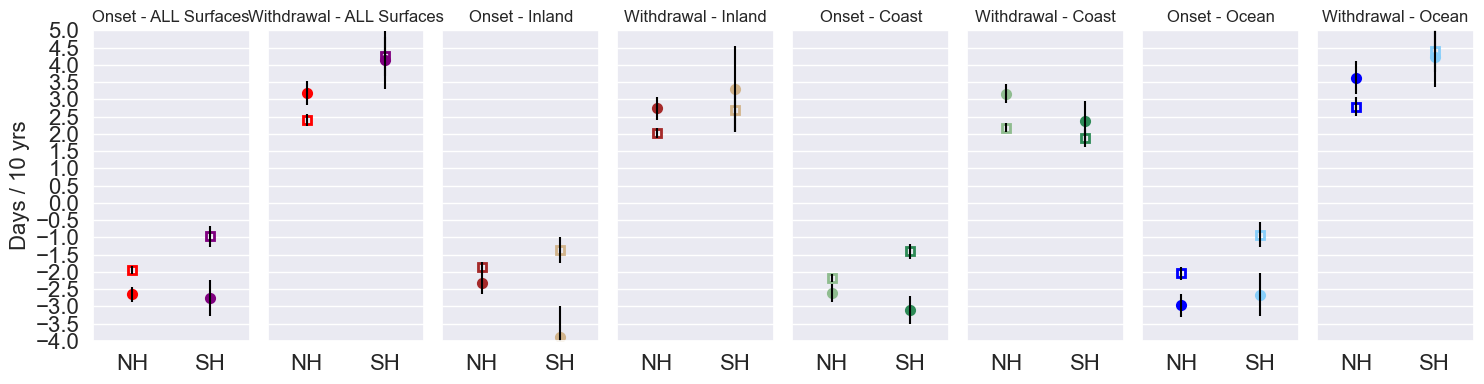

In [25]:
# plot params
ms = 6
palette_all={"NH": "red", "SH": "purple"}
palette_land={"NH": "brown", "SH": "tan"}
palette_coast={"NH": "darkseagreen", "SH": "seagreen"}
palette_ocean={"NH": "blue", "SH": "lightskyblue"}
xlabels = ['NH','SH']
#print(start_full, start_an)
#print(start_full, start_an)

fig=plt.figure(figsize=(15,4))#, layout='constrained')
#sns.set_context("paper")
### ALL surface average

ax1 = fig.add_subplot(1,8,1)
ax1=sns.pointplot(data=start_full, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax1.errorbar(start_full['Hemisphere'], start_full['Slope'], yerr=start_full['SE'], fmt="none", color="black")
ax1=sns.pointplot(data=start_an, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['o','o'], label="1990-2023", markersize=ms)
ax1.errorbar(start_an['Hemisphere'], start_an['Slope'], yerr=start_an['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax1.legend(loc='upper left')
ax1.set_xlabel("")
ax1.set_ylabel("Days / 10 yrs", fontsize=16)
ax1.set_title('Onset - ALL Surfaces')
ax1.set_yticks(np.arange(-4,6,0.5))
ax1.set_ylim(-4,5)

ax1.set_xlim(-0.5, len(xlabels)-0.5)
#ax1.xaxis.set_major_locator(ticker.FixedLocator([0, 1, 2]))
plt.tick_params('x', labelsize=16)

plt.tick_params('y', labelsize=16)

#plt.title('Summer Onset Trends')

ax2 = fig.add_subplot(1,8,2, sharey=ax1)
ax2 = sns.pointplot(data=end_full, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax2.errorbar(end_full['Hemisphere'], end_full['Slope'], yerr=end_full['SE'], fmt="none", color="black")
ax2 = sns.pointplot(data=end_an, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['o','o'], label="1990-2023", markersize=ms)
ax2.errorbar(end_an['Hemisphere'], end_an['Slope'], yerr=end_an['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax2.legend(loc='best')
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title('Withdrawal - ALL Surfaces')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax2.set_xlim(-0.5, len(xlabels)-0.5)


### Land

ax3 = fig.add_subplot(1,8,3, sharey=ax1)
ax3=sns.pointplot(data=start_full_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax3.errorbar(start_full_land['Hemisphere'], start_full_land['Slope'], yerr=start_full_land['SE'], fmt="none", color="black")
ax3=sns.pointplot(data=start_an_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['o','o'], label="1990-2023", markersize=ms)
ax3.errorbar(start_an_land['Hemisphere'], start_an_land['Slope'], yerr=start_an_land['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax3.legend(loc='upper left')
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_title('Onset - Inland')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax3.set_xlim(-0.5, len(xlabels)-0.5)


ax4 = fig.add_subplot(1,8,4, sharey=ax1)
ax4 = sns.pointplot(data=end_full_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax4.errorbar(end_full_land['Hemisphere'], end_full_land['Slope'], yerr=end_full_land['SE'], fmt="none", color="black",)
ax4 = sns.pointplot(data=end_an_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['o','o'], label="1990-2023", markersize=ms)
ax4.errorbar(end_an_land['Hemisphere'], end_an_land['Slope'], yerr=end_an_land['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax2.legend(loc='best')
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_title('Withdrawal - Inland')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax4.set_xlim(-0.5, len(xlabels)-0.5)


### Coast

ax5 = fig.add_subplot(1,8,5, sharey=ax1)
ax5=sns.pointplot(data=start_full_coast, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_coast, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax5.errorbar(start_full_coast['Hemisphere'], start_full_coast['Slope'], yerr=start_full_coast['SE'], fmt="none", color="black")
ax5=sns.pointplot(data=start_an_coast, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_coast, markers=['o','o'], label="1990-2023", markersize=ms)
ax5.errorbar(start_an_coast['Hemisphere'], start_an_coast['Slope'], yerr=start_an_coast['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax3.legend(loc='upper left')
ax5.set_xlabel("")
ax5.set_ylabel("")
ax5.set_title('Onset - Coast')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax5.set_xlim(-0.5, len(xlabels)-0.5)

ax6 = fig.add_subplot(1,8,6, sharey=ax1)
ax6 = sns.pointplot(data=end_full_coast, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_coast, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax6.errorbar(end_full_coast['Hemisphere'], end_full_coast['Slope'], yerr=end_full_coast['SE'], fmt="none", color="black",)
ax6 = sns.pointplot(data=end_an_coast, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_coast, markers=['o','o'], label="1990-2023", markersize=ms)
ax6.errorbar(end_an_coast['Hemisphere'], end_an_coast['Slope'], yerr=end_an_coast['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax2.legend(loc='best')
ax6.set_xlabel("")
ax6.set_ylabel("")
ax6.set_title('Withdrawal - Coast')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax6.set_xlim(-0.5, len(xlabels)-0.5)


### Ocean

ax7 = fig.add_subplot(1,8,7, sharey=ax1)
ax7=sns.pointplot(data=start_full_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax7.errorbar(start_full_ocean['Hemisphere'], start_full_ocean['Slope'], yerr=start_full_ocean['SE'], fmt="none", color="black")
ax7=sns.pointplot(data=start_an_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['o','o'], label="1990-2023", markersize=ms)
ax7.errorbar(start_an_ocean['Hemisphere'], start_an_ocean['Slope'], yerr=start_an_ocean['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax3.legend(loc='upper left')
ax7.set_xlabel("")
ax7.set_ylabel("")
ax7.set_title('Onset - Ocean')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax7.set_xlim(-0.5, len(xlabels)-0.5)

ax8 = fig.add_subplot(1,8,8, sharey=ax1)
ax8 = sns.pointplot(data=end_full_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax8.errorbar(end_full_ocean['Hemisphere'], end_full_ocean['Slope'], yerr=end_full_ocean['SE'], fmt="none", color="black",)
ax8 = sns.pointplot(data=end_an_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['o','o'], label="1990-2023", markersize=ms)
ax8.errorbar(end_an_ocean['Hemisphere'], end_an_ocean['Slope'], yerr=end_an_ocean['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax2.legend(loc='best')
ax8.set_xlabel("")
ax8.set_ylabel("")
ax8.set_title('Withdrawal - Ocean')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax8.set_xlim(-0.5, len(xlabels)-0.5)





plt.tight_layout()
plt.show()

#### Make the plots with onset positive

In [26]:
# take absolute value of all slopes to switch onsets to positive numbers
df_plot['Slope'] = np.abs(df_plot['Slope'])
df_plot

,Metric,Surface,Hemisphere,Slope,SE,Period
0,SummerStart,All,NH,1.95,0.12,1961-2023
1,SummerStart,Land,NH,1.85,0.12,1961-2023
2,SummerStart,Coast,NH,2.17,0.12,1961-2023
3,SummerStart,Ocean,NH,2.04,0.19,1961-2023
4,SummerStart,All,SH,0.97,0.31,1961-2023
...,...,...,...,...,...,...
59,SummerLength,Ocean,NH,6.60,0.71,1990-2023
60,SummerLength,All,SH,6.92,0.75,1990-2023
61,SummerLength,Land,SH,7.18,1.68,1990-2023
62,SummerLength,Coast,SH,5.48,0.71,1990-2023


In [27]:
# data slices
start_full = df_plot.query('Metric == "SummerStart" & Surface == "All" & Period == "1961-2023" ')
start_an = df_plot.query('Metric == "SummerStart" & Surface == "All" & Period == "1990-2023" ')
end_full = df_plot.query('Metric == "SummerEnd" & Surface == "All" & Period == "1961-2023" ')
end_an = df_plot.query('Metric == "SummerEnd" & Surface == "All" & Period == "1990-2023" ')

start_full_land = df_plot.query('Metric == "SummerStart" & Surface == "Land" & Period == "1961-2023" ')
start_an_land = df_plot.query('Metric == "SummerStart" & Surface == "Land" & Period == "1990-2023" ')
end_full_land = df_plot.query('Metric == "SummerEnd" & Surface == "Land" & Period == "1961-2023" ')
end_an_land = df_plot.query('Metric == "SummerEnd" & Surface == "Land" & Period == "1990-2023" ')

start_full_coast = df_plot.query('Metric == "SummerStart" & Surface == "Coast" & Period == "1961-2023" ')
start_an_coast = df_plot.query('Metric == "SummerStart" & Surface == "Coast" & Period == "1990-2023" ')
end_full_coast = df_plot.query('Metric == "SummerEnd" & Surface == "Coast" & Period == "1961-2023" ')
end_an_coast = df_plot.query('Metric == "SummerEnd" & Surface == "Coast" & Period == "1990-2023" ')

start_full_ocean = df_plot.query('Metric == "SummerStart" & Surface == "Ocean" & Period == "1961-2023" ')
start_an_ocean = df_plot.query('Metric == "SummerStart" & Surface == "Ocean" & Period == "1990-2023" ')
end_full_ocean = df_plot.query('Metric == "SummerEnd" & Surface == "Ocean" & Period == "1961-2023" ')
end_an_ocean = df_plot.query('Metric == "SummerEnd" & Surface == "Ocean" & Period == "1990-2023" ')

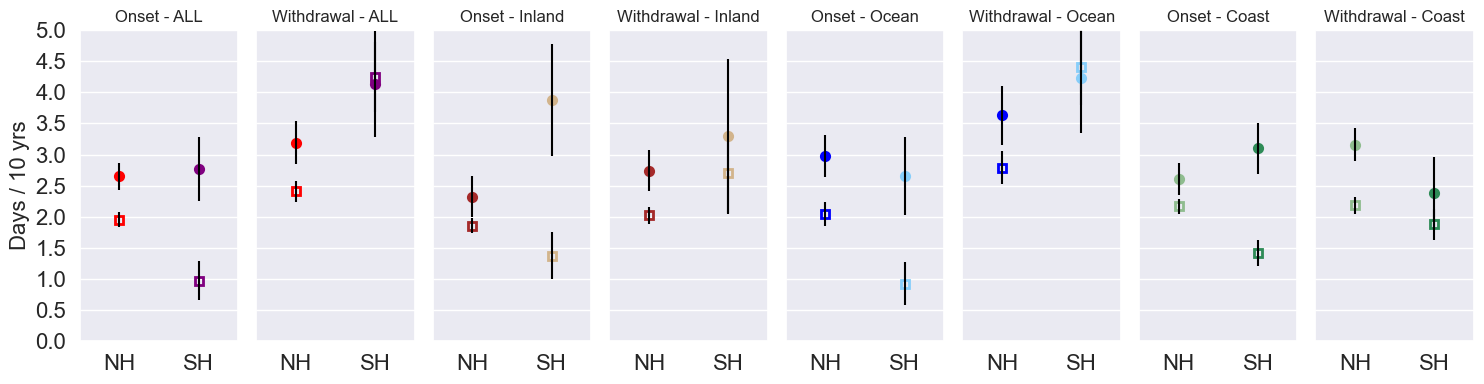

In [28]:
# plot params
ms = 6
palette_all={"NH": "red", "SH": "purple"}
palette_land={"NH": "brown", "SH": "tan"}
palette_coast={"NH": "darkseagreen", "SH": "seagreen"}
palette_ocean={"NH": "blue", "SH": "lightskyblue"}
xlabels = ['NH','SH']
#print(start_full, start_an)
#print(start_full, start_an)

fig=plt.figure(figsize=(15,4))#, layout='constrained')
#sns.set_context("paper")
### ALL surface average

ax1 = fig.add_subplot(1,8,1)
ax1=sns.pointplot(data=start_full, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax1.errorbar(start_full['Hemisphere'], start_full['Slope'], yerr=start_full['SE'], fmt="none", color="black")
ax1=sns.pointplot(data=start_an, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['o','o'], label="1990-2023", markersize=ms)
ax1.errorbar(start_an['Hemisphere'], start_an['Slope'], yerr=start_an['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax1.legend(loc='upper left')
ax1.set_xlabel("")
ax1.set_ylabel("Days / 10 yrs", fontsize=16)
ax1.set_title('Onset - ALL', fontsize=12)
ax1.set_yticks(np.arange(0,6,0.5))
ax1.set_ylim(0,5)

ax1.set_xlim(-0.5, len(xlabels)-0.5)
#ax1.xaxis.set_major_locator(ticker.FixedLocator([0, 1, 2]))
plt.tick_params('x', labelsize=16)

plt.tick_params('y', labelsize=16)

#plt.title('Summer Onset Trends')

ax2 = fig.add_subplot(1,8,2, sharey=ax1)
ax2 = sns.pointplot(data=end_full, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax2.errorbar(end_full['Hemisphere'], end_full['Slope'], yerr=end_full['SE'], fmt="none", color="black")
ax2 = sns.pointplot(data=end_an, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['o','o'], label="1990-2023", markersize=ms)
ax2.errorbar(end_an['Hemisphere'], end_an['Slope'], yerr=end_an['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax2.legend(loc='best')
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title('Withdrawal - ALL', fontsize=12)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax2.set_xlim(-0.5, len(xlabels)-0.5)


### Land

ax3 = fig.add_subplot(1,8,3, sharey=ax1)
ax3=sns.pointplot(data=start_full_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax3.errorbar(start_full_land['Hemisphere'], start_full_land['Slope'], yerr=start_full_land['SE'], fmt="none", color="black")
ax3=sns.pointplot(data=start_an_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['o','o'], label="1990-2023", markersize=ms)
ax3.errorbar(start_an_land['Hemisphere'], start_an_land['Slope'], yerr=start_an_land['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax3.legend(loc='upper left')
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_title('Onset - Inland', fontsize=12)

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax3.set_xlim(-0.5, len(xlabels)-0.5)


ax4 = fig.add_subplot(1,8,4, sharey=ax1)
ax4 = sns.pointplot(data=end_full_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax4.errorbar(end_full_land['Hemisphere'], end_full_land['Slope'], yerr=end_full_land['SE'], fmt="none", color="black",)
ax4 = sns.pointplot(data=end_an_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['o','o'], label="1990-2023", markersize=ms)
ax4.errorbar(end_an_land['Hemisphere'], end_an_land['Slope'], yerr=end_an_land['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax2.legend(loc='best')
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_title('Withdrawal - Inland', fontsize=12)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax4.set_xlim(-0.5, len(xlabels)-0.5)

### Ocean

ax7 = fig.add_subplot(1,8,5, sharey=ax1)
ax7=sns.pointplot(data=start_full_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax7.errorbar(start_full_ocean['Hemisphere'], start_full_ocean['Slope'], yerr=start_full_ocean['SE'], fmt="none", color="black")
ax7=sns.pointplot(data=start_an_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['o','o'], label="1990-2023", markersize=ms)
ax7.errorbar(start_an_ocean['Hemisphere'], start_an_ocean['Slope'], yerr=start_an_ocean['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax3.legend(loc='upper left')
ax7.set_xlabel("")
ax7.set_ylabel("")
ax7.set_title('Onset - Ocean', fontsize=12)

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax7.set_xlim(-0.5, len(xlabels)-0.5)

ax8 = fig.add_subplot(1,8,6, sharey=ax1)
ax8 = sns.pointplot(data=end_full_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax8.errorbar(end_full_ocean['Hemisphere'], end_full_ocean['Slope'], yerr=end_full_ocean['SE'], fmt="none", color="black",)
ax8 = sns.pointplot(data=end_an_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['o','o'], label="1990-2023", markersize=ms)
ax8.errorbar(end_an_ocean['Hemisphere'], end_an_ocean['Slope'], yerr=end_an_ocean['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax2.legend(loc='best')
ax8.set_xlabel("")
ax8.set_ylabel("")
ax8.set_title('Withdrawal - Ocean', fontsize=12)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax8.set_xlim(-0.5, len(xlabels)-0.5)

### Coast

ax5 = fig.add_subplot(1,8,7, sharey=ax1)
ax5=sns.pointplot(data=start_full_coast, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_coast, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax5.errorbar(start_full_coast['Hemisphere'], start_full_coast['Slope'], yerr=start_full_coast['SE'], fmt="none", color="black")
ax5=sns.pointplot(data=start_an_coast, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_coast, markers=['o','o'], label="1990-2023", markersize=ms)
ax5.errorbar(start_an_coast['Hemisphere'], start_an_coast['Slope'], yerr=start_an_coast['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax3.legend(loc='upper left')
ax5.set_xlabel("")
ax5.set_ylabel("")
ax5.set_title('Onset - Coast', fontsize=12)

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax5.set_xlim(-0.5, len(xlabels)-0.5)

ax6 = fig.add_subplot(1,8,8, sharey=ax1)
ax6 = sns.pointplot(data=end_full_coast, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_coast, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax6.errorbar(end_full_coast['Hemisphere'], end_full_coast['Slope'], yerr=end_full_coast['SE'], fmt="none", color="black",)
ax6 = sns.pointplot(data=end_an_coast, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_coast, markers=['o','o'], label="1990-2023", markersize=ms)
ax6.errorbar(end_an_coast['Hemisphere'], end_an_coast['Slope'], yerr=end_an_coast['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax2.legend(loc='best')
ax6.set_xlabel("")
ax6.set_ylabel("")
ax6.set_title('Withdrawal - Coast', fontsize=12)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax6.set_xlim(-0.5, len(xlabels)-0.5)








plt.tight_layout()
plt.show()

In [29]:
df_plot.query('Hemisphere == "SH" & Metric == "SummerLength"')

,Metric,Surface,Hemisphere,Slope,SE,Period
52,SummerLength,All,SH,5.22,0.41,1961-2023
53,SummerLength,Land,SH,4.07,0.68,1961-2023
54,SummerLength,Coast,SH,3.29,0.31,1961-2023
55,SummerLength,Ocean,SH,5.34,0.42,1961-2023
60,SummerLength,All,SH,6.92,0.75,1990-2023
61,SummerLength,Land,SH,7.18,1.68,1990-2023
62,SummerLength,Coast,SH,5.48,0.71,1990-2023
63,SummerLength,Ocean,SH,6.90,0.76,1990-2023


#### Onset vs Withdrawal instead of by Hemisphere

In [30]:
# data slices
nh_full = df_plot.query('Hemisphere == "NH" & Metric in ["SummerStart","SummerEnd"] & Surface == "All" & Period == "1961-2023" ')
nh_an = df_plot.query('Hemisphere == "NH" & Metric in ["SummerStart","SummerEnd"] & Surface == "All" & Period == "1990-2023" ')
sh_full = df_plot.query('Hemisphere == "SH" & Metric in ["SummerStart","SummerEnd"] & Surface == "All" & Period == "1961-2023" ')
sh_an = df_plot.query('Hemisphere == "SH" & Metric in ["SummerStart","SummerEnd"] & Surface == "All" & Period == "1990-2023" ')

nh_full_land = df_plot.query('Hemisphere == "NH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Land" & Period == "1961-2023" ')
nh_an_land = df_plot.query('Hemisphere == "NH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Land" & Period == "1990-2023" ')
sh_full_land = df_plot.query('Hemisphere == "SH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Land" & Period == "1961-2023" ')
sh_an_land = df_plot.query('Hemisphere == "SH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Land" & Period == "1990-2023" ')

nh_full_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Ocean" & Period == "1961-2023" ')
nh_an_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Ocean" & Period == "1990-2023" ')
sh_full_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Ocean" & Period == "1961-2023" ')
sh_an_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Ocean" & Period == "1990-2023" ')

nh_full_coast = df_plot.query('Hemisphere == "NH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Coast" & Period == "1961-2023" ')
nh_an_coast = df_plot.query('Hemisphere == "NH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Coast" & Period == "1990-2023" ')
sh_full_coast = df_plot.query('Hemisphere == "SH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Coast" & Period == "1961-2023" ')
sh_an_coast = df_plot.query('Hemisphere == "SH" & Metric in ["SummerStart","SummerEnd"] & Surface == "Coast" & Period == "1990-2023" ')

nh_full

,Metric,Surface,Hemisphere,Slope,SE,Period
0,SummerStart,All,NH,1.95,0.12,1961-2023
16,SummerEnd,All,NH,2.41,0.17,1961-2023


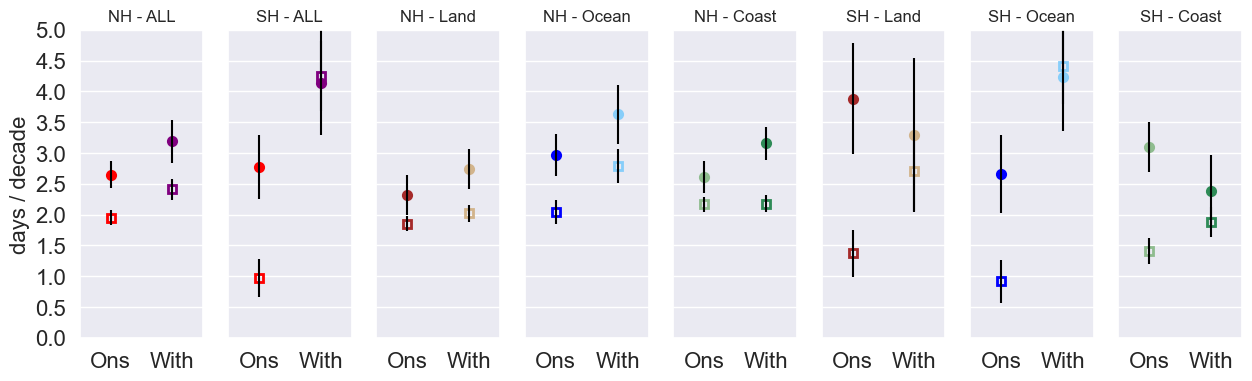

In [31]:
# plot params
ms = 6
palette_all={"SummerStart": "red", "SummerEnd": "purple"}
palette_land={"SummerStart": "brown", "SummerEnd": "tan"}
palette_coast={"SummerStart": "darkseagreen", "SummerEnd": "seagreen"}
palette_ocean={"SummerStart": "blue", "SummerEnd": "lightskyblue"}
xlabels = ['Ons','With']


fig=plt.figure(figsize=(15,4))#, layout='constrained')
#sns.set_context("paper")

### NH ALL surface average
ax1 = fig.add_subplot(1,8,1)
ax1 = sns.pointplot(data=nh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax1.errorbar(nh_full['Metric'], nh_full['Slope'], yerr=nh_full['SE'], fmt="none", color="black")
ax1 = sns.pointplot(data=nh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2023", markersize=ms)
ax1.errorbar(nh_an['Metric'], nh_an['Slope'], yerr=nh_an['SE'], fmt="none", color="black")
ax1.set_xticks(ticks=[0,1], labels=xlabels)
ax1.set_xlabel("")
ax1.set_ylabel("days / decade", fontsize=16)
ax1.set_title('NH - ALL', fontsize=12)
ax1.set_yticks(np.arange(0,6,0.5))
ax1.set_ylim(0,5)
ax1.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16)

### SH ALL surface average
ax2 = fig.add_subplot(1,8,2, sharey=ax1)
ax2=sns.pointplot(data=sh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax2.errorbar(sh_full['Metric'], sh_full['Slope'], yerr=sh_full['SE'], fmt="none", color="black")
ax2=sns.pointplot(data=sh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2023", markersize=ms)
ax2.errorbar(sh_an['Metric'], sh_an['Slope'], yerr=sh_an['SE'], fmt="none", color="black")
ax2.set_xticks(ticks=[0,1], labels=xlabels)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title('SH - ALL', fontsize=12)
ax2.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Land surface average
ax3 = fig.add_subplot(1,8,3, sharey=ax1)
ax3 = sns.pointplot(data=nh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax3.errorbar(nh_full_land['Metric'], nh_full_land['Slope'], yerr=nh_full_land['SE'], fmt="none", color="black")
ax3 = sns.pointplot(data=nh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2023", markersize=ms)
ax3.errorbar(nh_an_land['Metric'], nh_an_land['Slope'], yerr=nh_an_land['SE'], fmt="none", color="black")
ax3.set_xticks(ticks=[0,1], labels=xlabels)
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_title('NH - Land', fontsize=12)
ax3.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Ocean surface average
ax4 = fig.add_subplot(1,8,4, sharey=ax1)
ax4 = sns.pointplot(data=nh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax4.errorbar(nh_full_ocean['Metric'], nh_full_ocean['Slope'], yerr=nh_full_ocean['SE'], fmt="none", color="black")
ax4 = sns.pointplot(data=nh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2023", markersize=ms)
ax4.errorbar(nh_an_ocean['Metric'], nh_an_ocean['Slope'], yerr=nh_an_ocean['SE'], fmt="none", color="black")
ax4.set_xticks(ticks=[0,1], labels=xlabels)
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_title('NH - Ocean', fontsize=12)
ax4.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Coast surface average
ax5 = fig.add_subplot(1,8,5, sharey=ax1)
ax5 = sns.pointplot(data=nh_full_coast, x='Metric', y="Slope", hue="Metric", palette=palette_coast, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax5.errorbar(nh_full_coast['Metric'], nh_full_coast['Slope'], yerr=nh_full_coast['SE'], fmt="none", color="black")
ax5 = sns.pointplot(data=nh_an_coast, x="Metric", y="Slope", hue="Metric", palette=palette_coast, markers=['o','o'], label="1990-2023", markersize=ms)
ax5.errorbar(nh_an_coast['Metric'], nh_an_coast['Slope'], yerr=nh_an_coast['SE'], fmt="none", color="black")
ax5.set_xticks(ticks=[0,1], labels=xlabels)
ax5.set_xlabel("")
ax5.set_ylabel("")
ax5.set_title('NH - Coast', fontsize=12)
ax5.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Land surface average
ax6 = fig.add_subplot(1,8,6, sharey=ax1)
ax6 = sns.pointplot(data=sh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax6.errorbar(sh_full_land['Metric'], sh_full_land['Slope'], yerr=sh_full_land['SE'], fmt="none", color="black")
ax6 = sns.pointplot(data=sh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2023", markersize=ms)
ax6.errorbar(sh_an_land['Metric'], sh_an_land['Slope'], yerr=sh_an_land['SE'], fmt="none", color="black")
ax6.set_xticks(ticks=[0,1], labels=xlabels)
ax6.set_xlabel("")
ax6.set_ylabel("")
ax6.set_title('SH - Land', fontsize=12)
ax6.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Ocean surface average
ax7 = fig.add_subplot(1,8,7, sharey=ax1)
ax7 = sns.pointplot(data=sh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax7.errorbar(sh_full_ocean['Metric'], sh_full_ocean['Slope'], yerr=sh_full_ocean['SE'], fmt="none", color="black")
ax7 = sns.pointplot(data=sh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2023", markersize=ms)
ax7.errorbar(sh_an_ocean['Metric'], sh_an_ocean['Slope'], yerr=sh_an_ocean['SE'], fmt="none", color="black")
ax7.set_xticks(ticks=[0,1], labels=xlabels)
ax7.set_xlabel("")
ax7.set_ylabel("")
ax7.set_title('SH - Ocean', fontsize=12)
ax7.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Coast surface average
ax8 = fig.add_subplot(1,8,8, sharey=ax1)
ax8 = sns.pointplot(data=sh_full_coast, x='Metric', y="Slope", hue="Metric", palette=palette_coast, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax8.errorbar(sh_full_coast['Metric'], sh_full_coast['Slope'], yerr=sh_full_coast['SE'], fmt="none", color="black")
ax8 = sns.pointplot(data=sh_an_coast, x="Metric", y="Slope", hue="Metric", palette=palette_coast, markers=['o','o'], label="1990-2023", markersize=ms)
ax8.errorbar(sh_an_coast['Metric'], sh_an_coast['Slope'], yerr=sh_an_coast['SE'], fmt="none", color="black")
ax8.set_xticks(ticks=[0,1], labels=xlabels)
ax8.set_xlabel("")
ax8.set_ylabel("")
ax8.set_title('SH - Coast', fontsize=12)
ax8.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)



plt.show()


#### Grouped by Hemisphere and error as 95% conf intervals

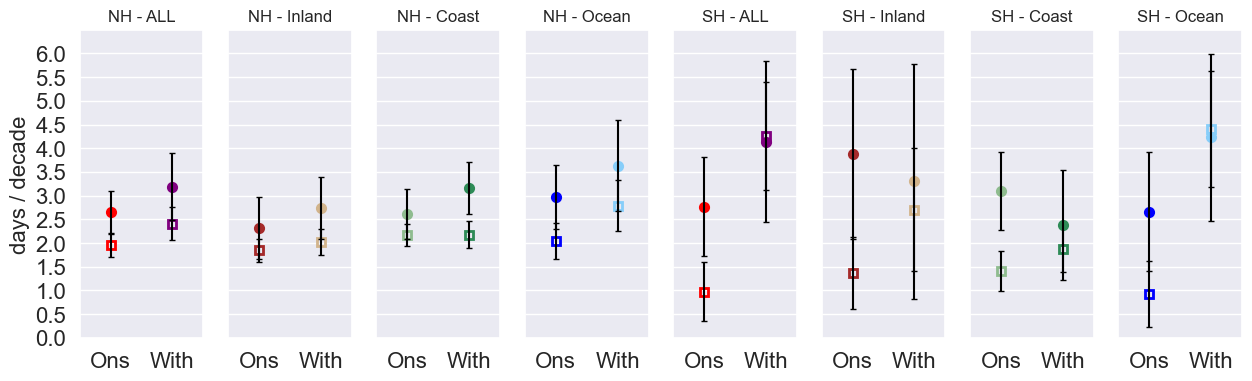

In [32]:
# plot params
ms = 6
caps = 2
palette_all={"SummerStart": "red", "SummerEnd": "purple"}
palette_land={"SummerStart": "brown", "SummerEnd": "tan"}
palette_coast={"SummerStart": "darkseagreen", "SummerEnd": "seagreen"}
palette_ocean={"SummerStart": "blue", "SummerEnd": "lightskyblue"}
xlabels = ['Ons','With']


fig=plt.figure(figsize=(15,4))#, layout='constrained')
#sns.set_context("paper")

#### Errors are multiplied by 2 to show 95% confidence values instead of 1 SE)


### NH ALL surface average
ax1 = fig.add_subplot(1,8,1)
ax1 = sns.pointplot(data=nh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax1.errorbar(nh_full['Metric'], nh_full['Slope'], yerr=2*nh_full['SE'], fmt="none", color="black", capsize=caps)
ax1 = sns.pointplot(data=nh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2023", markersize=ms)
ax1.errorbar(nh_an['Metric'], nh_an['Slope'], yerr=2*nh_an['SE'], fmt="none", color="black", capsize=caps)
ax1.set_xticks(ticks=[0,1], labels=xlabels)
ax1.set_xlabel("")
ax1.set_ylabel("days / decade", fontsize=16)
ax1.set_title('NH - ALL', fontsize=12)
ax1.set_yticks(np.arange(0,6.5,0.5))
ax1.set_ylim(0,6.5)
ax1.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16)


### NH Land surface average
ax3 = fig.add_subplot(1,8,2, sharey=ax1)
ax3 = sns.pointplot(data=nh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax3.errorbar(nh_full_land['Metric'], nh_full_land['Slope'], yerr=2*nh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax3 = sns.pointplot(data=nh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2023", markersize=ms)
ax3.errorbar(nh_an_land['Metric'], nh_an_land['Slope'], yerr=2*nh_an_land['SE'], fmt="none", color="black", capsize=caps)
ax3.set_xticks(ticks=[0,1], labels=xlabels)
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_title('NH - Inland', fontsize=12)
ax3.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Ocean surface average
ax4 = fig.add_subplot(1,8,4, sharey=ax1)
ax4 = sns.pointplot(data=nh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax4.errorbar(nh_full_ocean['Metric'], nh_full_ocean['Slope'], yerr=2*nh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax4 = sns.pointplot(data=nh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2023", markersize=ms)
ax4.errorbar(nh_an_ocean['Metric'], nh_an_ocean['Slope'], yerr=2*nh_an_ocean['SE'], fmt="none", color="black", capsize=caps)
ax4.set_xticks(ticks=[0,1], labels=xlabels)
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_title('NH - Ocean', fontsize=12)
ax4.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Coast surface average
ax5 = fig.add_subplot(1,8,3, sharey=ax1)
ax5 = sns.pointplot(data=nh_full_coast, x='Metric', y="Slope", hue="Metric", palette=palette_coast, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax5.errorbar(nh_full_coast['Metric'], nh_full_coast['Slope'], yerr=2*nh_full_coast['SE'], fmt="none", color="black", capsize=caps)
ax5 = sns.pointplot(data=nh_an_coast, x="Metric", y="Slope", hue="Metric", palette=palette_coast, markers=['o','o'], label="1990-2023", markersize=ms)
ax5.errorbar(nh_an_coast['Metric'], nh_an_coast['Slope'], yerr=2*nh_an_coast['SE'], fmt="none", color="black", capsize=caps)
ax5.set_xticks(ticks=[0,1], labels=xlabels)
ax5.set_xlabel("")
ax5.set_ylabel("")
ax5.set_title('NH - Coast', fontsize=12)
ax5.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)


### SH ALL surface average
ax2 = fig.add_subplot(1,8,5, sharey=ax1)
ax2=sns.pointplot(data=sh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax2.errorbar(sh_full['Metric'], sh_full['Slope'], yerr=2*sh_full['SE'], fmt="none", color="black", capsize=caps)
ax2=sns.pointplot(data=sh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2023", markersize=ms)
ax2.errorbar(sh_an['Metric'], sh_an['Slope'], yerr=2*sh_an['SE'], fmt="none", color="black", capsize=caps)
ax2.set_xticks(ticks=[0,1], labels=xlabels)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title('SH - ALL', fontsize=12)
ax2.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Land surface average
ax6 = fig.add_subplot(1,8,6, sharey=ax1)
ax6 = sns.pointplot(data=sh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax6.errorbar(sh_full_land['Metric'], sh_full_land['Slope'], yerr=2*sh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax6 = sns.pointplot(data=sh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2023", markersize=ms)
ax6.errorbar(sh_an_land['Metric'], sh_an_land['Slope'], yerr=2*sh_an_land['SE'], fmt="none", capsize=caps, color="black")
ax6.set_xticks(ticks=[0,1], labels=xlabels)
ax6.set_xlabel("")
ax6.set_ylabel("")
ax6.set_title('SH - Inland', fontsize=12)
ax6.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Ocean surface average
ax7 = fig.add_subplot(1,8,8, sharey=ax1)
ax7 = sns.pointplot(data=sh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax7.errorbar(sh_full_ocean['Metric'], sh_full_ocean['Slope'], yerr=2*sh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax7 = sns.pointplot(data=sh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2023", markersize=ms)
ax7.errorbar(sh_an_ocean['Metric'], sh_an_ocean['Slope'], yerr=2*sh_an_ocean['SE'], fmt="none", capsize=caps, color="black")
ax7.set_xticks(ticks=[0,1], labels=xlabels)
ax7.set_xlabel("")
ax7.set_ylabel("")
ax7.set_title('SH - Ocean', fontsize=12)
ax7.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Coast surface average
ax8 = fig.add_subplot(1,8,7, sharey=ax1)
ax8 = sns.pointplot(data=sh_full_coast, x='Metric', y="Slope", hue="Metric", palette=palette_coast, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax8.errorbar(sh_full_coast['Metric'], sh_full_coast['Slope'], yerr=2*sh_full_coast['SE'], fmt="none", color="black", capsize=caps)
ax8 = sns.pointplot(data=sh_an_coast, x="Metric", y="Slope", hue="Metric", palette=palette_coast, markers=['o','o'], label="1990-2023", markersize=ms)
ax8.errorbar(sh_an_coast['Metric'], sh_an_coast['Slope'], yerr=2*sh_an_coast['SE'], fmt="none", capsize=caps, color="black")
ax8.set_xticks(ticks=[0,1], labels=xlabels)
ax8.set_xlabel("")
ax8.set_ylabel("")
ax8.set_title('SH - Coast', fontsize=12)
ax8.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)


plt.savefig("./Plots/All_Hemispheric_Onset_Withdrawal_Trends_with_error.png",bbox_inches='tight')
plt.savefig("./Plots/All_Hemispheric_Onset_Withdrawal_Trends_with_error.pdf",bbox_inches='tight')

plt.show()


### Test for Stat Sig slope differences between onset and withdrawal 1990-2023

In [78]:
# help from https://stackoverflow.com/questions/66110650/how-to-compare-the-slopes-of-two-regression-lines
# and https://www.statsmodels.org/stable/examples/notebooks/generated/ols.html
x=np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
blue_y = np.array([0.94732871, 0.85729212, 0.86039587, 0.89169027, 0.90817473, 0.93606619, 0.93890423, 1., 0.97783521, 0.93035495])
light_blue_y = np.array([0.81346023, 0.72248919, 0.72406021, 0.74823437, 0.77759055, 0.81167983,  0.84050726, 0.90357904, 0.97354455, 1. ])

y = blue_y-light_blue_y
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
print(res.summary())
#dir(res)
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("contains zero") 
else: 
    print("sig")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.603
Method:                 Least Squares   F-statistic:                     14.67
Date:                Fri, 11 Jul 2025   Prob (F-statistic):            0.00502
Time:                        11:22:31   Log-Likelihood:                 18.081
No. Observations:                  10   AIC:                            -32.16
Df Residuals:                       8   BIC:                            -31.56
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1775      0.026      6.807      0.0

In [33]:
%%time
# build datasets again because I rewrote their names above :(

nh_an_dat = ds.sel(time=slice('1990','2023')).where(((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])
sh_an_dat = ds.sel(time=slice('1990','2023')).where(((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])


nh_land_an_dat = ds.sel(time=slice('1990','2023')).where((ds.lsm > 0.5)  & (ds.Coastal == False) & #& (ds.SummerMeanT > 0)
                                                          ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_coast_an_dat = ds.sel(time=slice('1990','2023')).where((ds.Coastal)  & #& (ds.SummerMeanT > 0)
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_an_dat = ds.sel(time=slice('1990','2023')).where((ds.lsm > 0.5)  & (ds.Coastal == False) & #& (ds.SummerMeanT > 0)
                                                          ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_coast_an_dat = ds.sel(time=slice('1990','2023')).where((ds.Coastal)  & #& (ds.SummerMeanT > 0)
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

nh_ocean_an_dat = ds.sel(time=slice('1990','2023')).where((ds.lsm <= 0.5) & #(ds.SummerMeanT > 0) &
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_an_dat = ds.sel(time=slice('1990','2023')).where((ds.lsm <= 0.5) & #(ds.SummerMeanT > 0) &
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])


CPU times: user 11.7 s, sys: 9.25 s, total: 21 s
Wall time: 22.5 s


In [90]:
x = nh_an_dat.time.dt.year.values
y1 = nh_an_dat.SummerStart.values
y2 = nh_an_dat.SummerEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)

# check with plot
# plt.plot(x,y2, c='blue')
# plt.plot(x,y1, c='red')
# plt.plot(x, y2-y1, c='green')

y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
#print(res.summary())
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

[-0.0045219   0.11222206]
not sig contains zero


In [91]:
x = nh_land_an_dat.time.dt.year.values
y1 = nh_land_an_dat.SummerStart.values
y2 = nh_land_an_dat.SummerEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)
y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

[-0.02356194  0.10682985]
not sig contains zero


In [92]:
x = nh_ocean_an_dat.time.dt.year.values
y1 = nh_ocean_an_dat.SummerStart.values
y2 = nh_ocean_an_dat.SummerEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)
y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

[-0.02064078  0.15225079]
not sig contains zero


#### NH Coast SIG *onset vs withdrawal*

[0.00496988 0.10436708]
sig


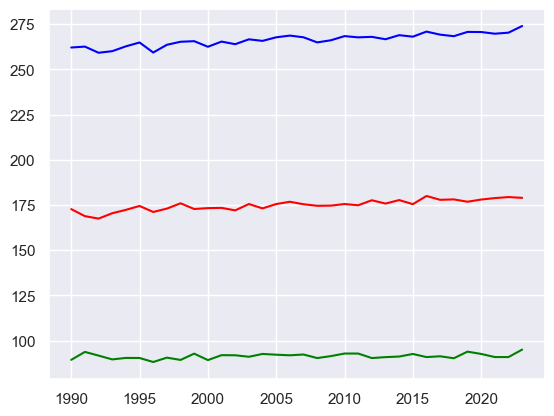

In [102]:
x = nh_coast_an_dat.time.dt.year.values
y1 = nh_coast_an_dat.SummerStart.values
y2 = nh_coast_an_dat.SummerEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)

# check with plot
plt.plot(x,y2, c='blue')
plt.plot(x,y1, c='red')
plt.plot(x, y2-y1, c='green')

y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

[-0.10625608  0.38008858]
not sig contains zero


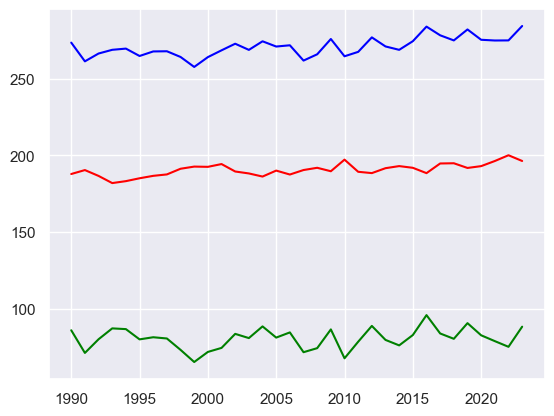

In [101]:
x = sh_an_dat.time.dt.year.values
y1 = sh_an_dat.SummerStart.values
y2 = sh_an_dat.SummerEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)

# check with plot
plt.plot(x,y2, c='blue')
plt.plot(x,y1, c='red')
plt.plot(x, y2-y1, c='green')

y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
#print(res.summary())
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

[-0.33813571  0.22359858]
not sig contains zero


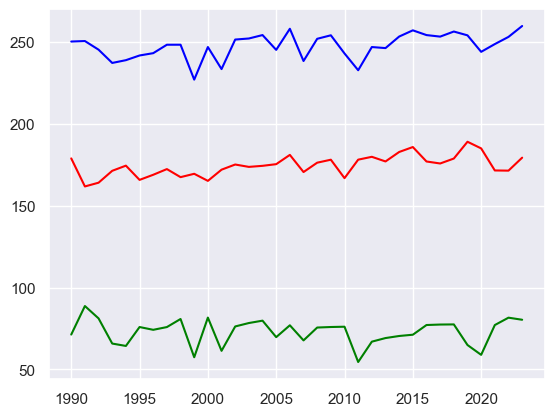

In [103]:
x = sh_land_an_dat.time.dt.year.values
y1 = sh_land_an_dat.SummerStart.values
y2 = sh_land_an_dat.SummerEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)

# check with plot
plt.plot(x,y2, c='blue')
plt.plot(x,y1, c='red')
plt.plot(x, y2-y1, c='green')

y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
#print(res.summary())
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

[-0.21632439  0.07139425]
not sig contains zero


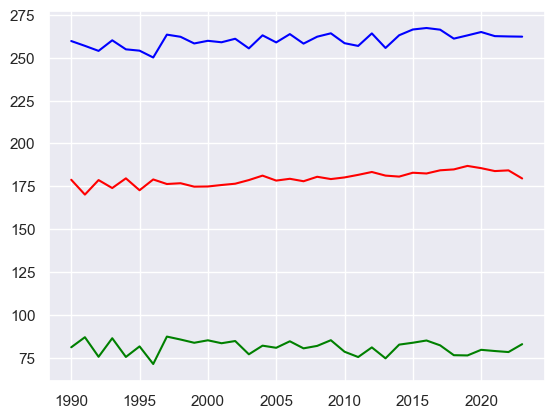

In [104]:
x = sh_coast_an_dat.time.dt.year.values
y1 = sh_coast_an_dat.SummerStart.values
y2 = sh_coast_an_dat.SummerEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)

# check with plot
plt.plot(x,y2, c='blue')
plt.plot(x,y1, c='red')
plt.plot(x, y2-y1, c='green')

y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
#print(res.summary())
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     1.406
Date:                Fri, 11 Jul 2025   Prob (F-statistic):              0.244
Time:                        16:47:46   Log-Likelihood:                -116.10
No. Observations:                  34   AIC:                             236.2
Df Residuals:                      32   BIC:                             239.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -236.2937    266.032     -0.888      0.3

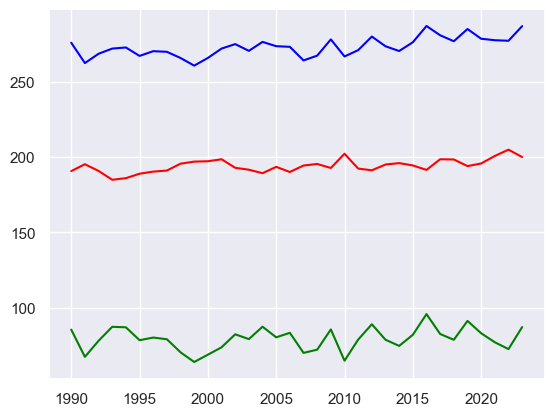

In [105]:
x = sh_ocean_an_dat.time.dt.year.values
y1 = sh_ocean_an_dat.SummerStart.values
y2 = sh_ocean_an_dat.SummerEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)

# check with plot
plt.plot(x,y2, c='blue')
plt.plot(x,y1, c='red')
plt.plot(x, y2-y1, c='green')

y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
print(res.summary())
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

In [34]:
df_plot.query('Metric in ["SummerHeat"] & Surface == "All" ')

,Metric,Surface,Hemisphere,Slope,SE,Period
32,SummerHeat,All,NH,25.42,1.60,1961-2023
36,SummerHeat,All,SH,11.49,0.76,1961-2023
40,SummerHeat,All,NH,39.00,3.27,1990-2023
44,SummerHeat,All,SH,16.03,1.69,1990-2023


### Accumulated Heat Plots

In [35]:
# data slices
nh_full = df_plot.query('Hemisphere == "NH" & Metric in ["SummerHeat"] & Surface == "All" & Period == "1961-2023" ')
nh_an = df_plot.query('Hemisphere == "NH" & Metric in ["SummerHeat"] & Surface == "All" & Period == "1990-2023" ')
sh_full = df_plot.query('Hemisphere == "SH" & Metric in ["SummerHeat"] & Surface == "All" & Period == "1961-2023" ')
sh_an = df_plot.query('Hemisphere == "SH" & Metric in ["SummerHeat"] & Surface == "All" & Period == "1990-2023" ')

nh_full_land = df_plot.query('Hemisphere == "NH" & Metric in ["SummerHeat"] & Surface == "Land" & Period == "1961-2023" ')
nh_an_land = df_plot.query('Hemisphere == "NH" & Metric in ["SummerHeat"] & Surface == "Land" & Period == "1990-2023" ')
sh_full_land = df_plot.query('Hemisphere == "SH" & Metric in ["SummerHeat"] & Surface == "Land" & Period == "1961-2023" ')
sh_an_land = df_plot.query('Hemisphere == "SH" & Metric in ["SummerHeat"] & Surface == "Land" & Period == "1990-2023" ')

nh_full_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["SummerHeat"] & Surface == "Ocean" & Period == "1961-2023" ')
nh_an_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["SummerHeat"] & Surface == "Ocean" & Period == "1990-2023" ')
sh_full_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["SummerHeat"] & Surface == "Ocean" & Period == "1961-2023" ')
sh_an_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["SummerHeat"] & Surface == "Ocean" & Period == "1990-2023" ')

nh_full_coast = df_plot.query('Hemisphere == "NH" & Metric in ["SummerHeat"] & Surface == "Coast" & Period == "1961-2023" ')
nh_an_coast = df_plot.query('Hemisphere == "NH" & Metric in ["SummerHeat"] & Surface == "Coast" & Period == "1990-2023" ')
sh_full_coast = df_plot.query('Hemisphere == "SH" & Metric in ["SummerHeat"] & Surface == "Coast" & Period == "1961-2023" ')
sh_an_coast = df_plot.query('Hemisphere == "SH" & Metric in ["SummerHeat"] & Surface == "Coast" & Period == "1990-2023" ')

nh_full

,Metric,Surface,Hemisphere,Slope,SE,Period
32,SummerHeat,All,NH,25.42,1.6,1961-2023


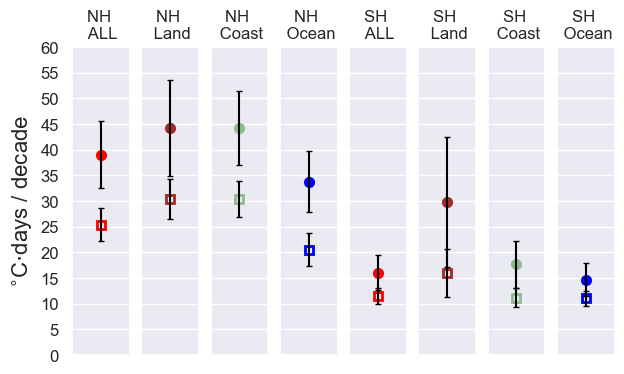

In [36]:
# plot params
ms = 6
caps = 2
palette_all={"SummerHeat": "red"}
palette_land={"SummerHeat": "brown"}
palette_coast={"SummerHeat": "darkseagreen"}
palette_ocean={"SummerHeat": "blue"}
xlabels = ['Heat']


fig=plt.figure(figsize=(7,4))#, layout='constrained')
#sns.set_context("paper")

#### Errors are multiplied by 2 to show 95% confidence values instead of 1 SE)


### NH ALL surface average
ax1 = fig.add_subplot(1,8,1)
ax1 = sns.pointplot(data=nh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax1.errorbar(nh_full['Metric'], nh_full['Slope'], yerr=2*nh_full['SE'], fmt="none", color="black", capsize=caps)
ax1 = sns.pointplot(data=nh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2023", markersize=ms)
ax1.errorbar(nh_an['Metric'], nh_an['Slope'], yerr=2*nh_an['SE'], fmt="none", color="black", capsize=caps)
#ax1.set_xticks(ticks=[0.5], labels=xlabels)
ax1.set_xlabel("")
ax1.set_ylabel("$^{\circ}$C$\cdot$days / decade", fontsize=16)
ax1.set_title('NH \n ALL', fontsize=12)
ax1.set_yticks(np.arange(0,70,5), minor=False)
ax1.set_ylim(0,60)
ax1.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=12)


### NH Land surface average
ax3 = fig.add_subplot(1,8,2, sharey=ax1)
ax3 = sns.pointplot(data=nh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax3.errorbar(nh_full_land['Metric'], nh_full_land['Slope'], yerr=2*nh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax3 = sns.pointplot(data=nh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2023", markersize=ms)
ax3.errorbar(nh_an_land['Metric'], nh_an_land['Slope'], yerr=2*nh_an_land['SE'], fmt="none", color="black", capsize=caps)
#ax3.set_xticks(ticks=[0,1], labels=xlabels)
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_title('NH \n Land', fontsize=12)
ax3.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Ocean surface average
ax4 = fig.add_subplot(1,8,4, sharey=ax1)
ax4 = sns.pointplot(data=nh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax4.errorbar(nh_full_ocean['Metric'], nh_full_ocean['Slope'], yerr=2*nh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax4 = sns.pointplot(data=nh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2023", markersize=ms)
ax4.errorbar(nh_an_ocean['Metric'], nh_an_ocean['Slope'], yerr=2*nh_an_ocean['SE'], fmt="none", color="black", capsize=caps)
#ax4.set_xticks(ticks=[0,1], labels=xlabels)
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_title('NH \n Ocean', fontsize=12)
ax4.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Coast surface average
ax5 = fig.add_subplot(1,8,3, sharey=ax1)
ax5 = sns.pointplot(data=nh_full_coast, x='Metric', y="Slope", hue="Metric", palette=palette_coast, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax5.errorbar(nh_full_coast['Metric'], nh_full_coast['Slope'], yerr=2*nh_full_coast['SE'], fmt="none", color="black", capsize=caps)
ax5 = sns.pointplot(data=nh_an_coast, x="Metric", y="Slope", hue="Metric", palette=palette_coast, markers=['o','o'], label="1990-2023", markersize=ms)
ax5.errorbar(nh_an_coast['Metric'], nh_an_coast['Slope'], yerr=2*nh_an_coast['SE'], fmt="none", color="black", capsize=caps)
#ax5.set_xticks(ticks=[0,1], labels=xlabels)
ax5.set_xlabel("")
ax5.set_ylabel("")
ax5.set_title('NH \n Coast', fontsize=12)
ax5.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)


### SH ALL surface average
ax2 = fig.add_subplot(1,8,5, sharey=ax1)
ax2=sns.pointplot(data=sh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax2.errorbar(sh_full['Metric'], sh_full['Slope'], yerr=2*sh_full['SE'], fmt="none", color="black", capsize=caps)
ax2=sns.pointplot(data=sh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2023", markersize=ms)
ax2.errorbar(sh_an['Metric'], sh_an['Slope'], yerr=2*sh_an['SE'], fmt="none", color="black", capsize=caps)
#ax2.set_xticks(ticks=[0,1], labels=xlabels)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title('SH \n ALL', fontsize=12)
ax2.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Land surface average
ax6 = fig.add_subplot(1,8,6, sharey=ax1)
ax6 = sns.pointplot(data=sh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax6.errorbar(sh_full_land['Metric'], sh_full_land['Slope'], yerr=2*sh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax6 = sns.pointplot(data=sh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2023", markersize=ms)
ax6.errorbar(sh_an_land['Metric'], sh_an_land['Slope'], yerr=2*sh_an_land['SE'], fmt="none", capsize=caps, color="black")
#ax6.set_xticks(ticks=[0,1], labels=xlabels)
ax6.set_xlabel("")
ax6.set_ylabel("")
ax6.set_title('SH \n Land', fontsize=12)
ax6.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Ocean surface average
ax7 = fig.add_subplot(1,8,8, sharey=ax1)
ax7 = sns.pointplot(data=sh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax7.errorbar(sh_full_ocean['Metric'], sh_full_ocean['Slope'], yerr=2*sh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax7 = sns.pointplot(data=sh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2023", markersize=ms)
ax7.errorbar(sh_an_ocean['Metric'], sh_an_ocean['Slope'], yerr=2*sh_an_ocean['SE'], fmt="none", capsize=caps, color="black")
#ax7.set_xticks(ticks=[0,1], labels=xlabels)
ax7.set_xlabel("")
ax7.set_ylabel("")
ax7.set_title('SH \n Ocean', fontsize=12)
ax7.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Coast surface average
ax8 = fig.add_subplot(1,8,7, sharey=ax1)
ax8 = sns.pointplot(data=sh_full_coast, x='Metric', y="Slope", hue="Metric", palette=palette_coast, markers=['s','s'], label="1961-2023", markersize=ms, fillstyle='none')
ax8.errorbar(sh_full_coast['Metric'], sh_full_coast['Slope'], yerr=2*sh_full_coast['SE'], fmt="none", color="black", capsize=caps)
ax8 = sns.pointplot(data=sh_an_coast, x="Metric", y="Slope", hue="Metric", palette=palette_coast, markers=['o','o'], label="1990-2023", markersize=ms)
ax8.errorbar(sh_an_coast['Metric'], sh_an_coast['Slope'], yerr=2*sh_an_coast['SE'], fmt="none", capsize=caps, color="black")
#ax8.set_xticks(ticks=[0,1], labels=xlabels)
ax8.set_xlabel("")
ax8.set_ylabel("")
ax8.set_title('SH \n Coast', fontsize=12)
ax8.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

plt.savefig("./Plots/AccumulatedHeat_Trends_by_surface_with_errorbars.png",bbox_inches='tight')
plt.savefig("./Plots/AccumulatedHeat_Trends_by_surface_with_errorbars.pdf",bbox_inches='tight')

plt.show()


In [302]:
from matplotlib import markers
print(markers.MarkerStyle.markers.keys())

dict_keys(['.', ',', 'o', 'v', '^', '<', '>', '1', '2', '3', '4', '8', 's', 'p', '*', 'h', 'H', '+', 'x', 'D', 'd', '|', '_', 'P', 'X', 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 'None', 'none', ' ', ''])
